
# 🎯 Goal: Building an Early Warning System


---

## Introduction: an Early Warning System based on Anomaly Detection

Financial assets, in the medium to long term, tend to generate **positive risk premia and positive real returns** — see for example [UBS Global Investment Returns Yearbook 2025](https://www.ubs.com/global/en/investment-bank/insights-and-data/articles/global-investment-returns-yearbook-2026.html) and [UBS Global Investment Returns Yearbook 2025](https://www.ubs.com/global/en/investment-bank/insights-and-data/2025/global-investment-returns-yearbook-2025.html), supported by basic economic principles:

- For **equities**, the return on capital invested in business activities.
- For **bonds**, the remuneration for:
  - the temporary deprivation of money (and consumption).
  - and the compensation for default risk.

However, financial markets periodically experience **crises** in which asset returns deviate from these principles for periods that may be short... or not.

Investor **risk appetite** fluctuates over time—rising in optimistic phases and falling during times of uncertainty. As a result, asset prices move accordingly.

In market jargon, we refer to:

- **Risk-on** situations:  
  >Investors are willing to take risks and bid up the prices of risky assets (equities, corporate bonds, riskier sovereign bonds, most commodities, etc.).

- **Risk-off** situations:  
  >Investors become more risk-averse, sell risky assets (driving prices down), and shift to safer investments (cash, short-term bonds of safe-haven countries, sometimes gold, etc.).  
  These periods are typically associated with **high systemic risk**.

Financial institutions would like to detect risk-on vs. risk-off regimes **as early as possible**: identifying these situations early – it's more *nowcasting* than *forecasting* – as it is often enough to significantly outperform the market and increase your reputation as an asset manager.

So, this is our motivation.

---

<br>

## 🧠 What are we trying to do?

We try to algorithmically detect risk-on vs. risk-off regimes using Data Science, a relatively new approach.

To formalize this:

- **Risk-on** periods ⟶ _Normal_
- **Risk-off** periods ⟶ _Abnormal_

We can use Machine Learning to create a model that identifies **financial anomalies** in real time: this would be an example of an **Early Warning System** built using **Anomaly Detection** techniques.

> More precisely, we are dealing with what is typically known as **Novelty Detection**, as opposed to **Outlier Detection**, both subfields of Anomaly Detection. Here the taxonomy and nomenclature are not univocal (generally: Novelty = supervised or semi-supervised, and Outlier = unsupervised), and to tell the truth not even very interesting: the important thing is to solve a problem...

This is just **one possible approach** to building such a an Early Warning System.  We focus on it because it's based on a widely used class of ML models and allows us to explore important ideas in unsupervised and supervised learning, useful for many other purposes in the Fintech field.


📖 **Further reading:**
- [A Survey of Systemic Risk Analytics – OFR Working Paper 0001](https://dx.doi.org/10.2139/ssrn.1983602)
- [A Systematic Review of Early Warning Systems in Finance](https://arxiv.org/pdf/2310.00490)
- [Systemic Risk Measures: Taking Stock from 1927 to 2023](https://www.nber.org/system/files/working_papers/w33211/w33211.pdf)


<br>


---


<br>

After a quick **warm-up using artificial data** to introduce some key concepts, we'll apply these concepts to a real-world dataset (from Bloomberg). The dataset is anonymous, mostly clean, but **not** transformed, normalized, or scaled.

The dataset is called `Dataset4_EWS.xlsx`.

<br>

In [ ]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

# Path to the dataset (relative to the notebook location)
DATA_PATH = "data/Dataset4_EWS.xlsx"

In [ ]:
import warnings
warnings.filterwarnings('ignore')

### **Introduction to Anomaly Detection - using artificial data**

We start with a simple but effective method for anomaly detection. We will uses synthetic data to better understand some key points.

#### 👁️‍🗨️ **God Mode = ON: we simulate the world**

We create a **synthetic universe of investment returns** where:

- **Normal data** comes from a 2D Gaussian with moderate variance and centered around $(1,1)$.
- **Abormal data = anomalies** drawn from a different Gaussian  
  with larger variance and centered far away at $(-5, -6)$ (of course, you can/should change the parameters of the Data Generation Process).


We generate:
- 10,000 normal points.
- 40 anomalies.

These are then combined into a single dataset for our Anomaly Detection experiment. So the overall density function is a **Gaussian Mixture** (btw: a fairly realistic distribution for market data).

But we know the full truth, or *ground truth* — because WE designed the system. So we can judge the model, any model on this dataset.


<br>

### **Data Visualization**

We plot the data in two ways:

- **Unlabeled scatter plot**: to visualize the full dataset as it would appear in a real setting.
- **Labeled scatter plot**: with anomalies highlighted, for inspection and model evaluation.

<br>


In [ ]:
from scipy.stats import multivariate_normal
from sklearn.metrics import precision_score, recall_score, f1_score

# Set the style for our plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]


# Set random seed for reproducibility
np.random.seed(42)

# First variable: "ordinary returns = non-anomalous data"
mu1 = np.array([1, 1])  # Mean of the 1st component
sigma1 = np.array([[1.7, 0.5], [0.5, 1.9]])  # Covariance of the 1st component
nobs1 = 10000

# Second variable: "unusual returns = anomalies"
mu2 = np.array([-5, -6])  # Mean of the 2nd component
sigma2 = np.array([[4.5, 0.95], [0.95, 3.5]])  # Covariance of the 2nd component
nobs2 = 40

# Generate random samples from multivariate normal distributions
r1 = np.random.multivariate_normal(mu1, sigma1, nobs1)
r2 = np.random.multivariate_normal(mu2, sigma2, nobs2)

# Combine the two sets into one dataset
X = np.vstack((r1, r2))
y = np.hstack((np.zeros(nobs1), np.ones(nobs2)))

# Plot the data without labels
plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c='k', s=10)
plt.xlabel('Investment return 1')
plt.ylabel('Investment return 2')
plt.title('Unlabeled returns')
plt.show()

# Plot the data with labels (anomalies in red)
plt.figure(figsize=(12, 8))
plt.scatter(X[y==0, 0], X[y==0, 1], c='k', s=10, label='Normal')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r', s=12, label='Anomaly')
plt.xlabel('Investment return 1')
plt.ylabel('Investment return 2')
plt.title('Labeled returns (i.e. anomalies are highlighted)')
plt.legend()
plt.show()



### **Modeling Strategy – God Mode = OFF**

So far, in "God Mode ON", we’ve created the world. Now we pretend we didn’t.

We step into the shoes of someone who:

- Observes a dataset coming from an unknown Data Generation Process (DGP).
- Knows which points are abnormal (at least a decent subset), for example because they have been labelled by an expert.
- Wants to detect which points are **abnormal**, i.e., **anomalies**.

A fairly typical situation.


Our strategy:

1. **Model the normal** – Fit a multivariate Gaussian (MVG) density only on the normal observations.
2. **Score everything** – Use the MVG to assign a likelihood score $p(x)$ to each new observation.
3. **Flag anomalies** – If $p(x)$ is lower than some threshold $\varepsilon$, we flag it as an anomaly.

This leads to a simple decision rule:

$$
\text{Anomaly} \quad \Longleftrightarrow \quad p(x) < \varepsilon
$$

This approach is probabilistic, quite interpretable, and (despite its simplicity) surprisingly effective when anomalies are rare and normality is structured.

---

#### 🧠 What are we really doing?

- We do **not** assume the entire dataset is Gaussian.  
  (In fact, we know it's a Gaussian mixture — but we ignore that on purpose.)

- We only assume that the **normal part** of the data can be well approximated by a multivariate Gaussian.

- We use the fitted MVG as a proxy for **how normality looks**, and measure how much new observations deviate from it.

> 💡 We’re not learning what anomalies *are*.  
> We’re learning what *normal* is — and flagging anything that looks very different.


---

#### Formal Summary

We fit:

- $\mu = \text{mean of normal data}$
- $\Sigma = \text{covariance of normal data}$

Then for any observation $x$:

$$
p(x) = \frac{1}{(2\pi)^{k/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x - \mu)^T \Sigma^{-1} (x - \mu)\right)
$$

We classify $x$ as **anomaly** if:

$$
p(x) < \varepsilon
$$

We choose our **hyperparamer** $\varepsilon$ by maximizing the **F1 score** on the validation set (which includes anomalies). Anyway, you can decide to maximize any metric you think is good as Optimization metric (F1 is just a reasonable and comfy choice).

---
<br>

 🧠 **Short Machine Learning epistemology note**

While the core method (fitting a multivariate Gaussian density) is unsupervised (because density estimation is an unsupervised metod), we apply it in a **supervised framework**:
- We use **labeled data** (anomalies) during cross-validation to choose the threshold $\varepsilon$. This means: supervised.
- We evaluate the model using **supervised metrics** like precision, recall, and F1 score.

So overall, this should be considered a **supervised model**. Or, **semi-supervised**. Again, it's just terminology.

📌 **Lesson**: the nature of a model depends not just on how it’s built,  but on how it’s **used** (also, think about Logistic Regression, a regression model typically used as a classifier).

<br>

### **Splitting data: Train / Cross-Validation / Test Set Construction**

We adopt the **fairly classic train/cv/test partition**. But there are some peculiarities though: in anomaly detection, **data is typically split in a way that emphasizes the modeling of normal behavior**.

<br>

#### **Training Set (`X_train`)**

- Contains only **normal data** (i.e., no anomalies).
- Extracted as the first 6,000 observations from the normal sample: `r1[:6000]`.
- Used to estimate the MVG distribution of "normal" behavior.

This is intentional:  
we want the model to learn the statistical structure of normal data **without contamination** from anomalies.

<br>

#### **Cross-Validation Set (`X_cross_val`)**

- Contains a **mixture** of:
  - 2,000 **normal** points: `r1[6000:8000]`.
  - 20 **anomalies** (50% of total anomalies): `r2[:20]`.
- Used to **tune the hyperparameter, the threshold** $\varepsilon$, which controls the anomaly detection cutoff.

<br>

#### **Test Set (`X_test`)**

- Also a **mixture** of:
  - 2,000 **normal** points: `r1[8000:]`.
  - 20 **anomalies** (remaining 50%): `r2[20:]`.
- Used to evaluate the **final performance** of the trained model on **unseen data** (i.e., out-of-sample, or using the hold-out set).

<br>

---

This data split structure is common in Anomaly Detection when:

- Anomalies are **rare** (which is often the case, btw, otherwise they are not considered anomalies...).
- The goal is to carefully model "normal" data.
- There are **not enough anomalies** to learn their distribution directly

Note that this setup differs from standard supervised learning, where all classes are typically distributed proportionally across training, validation, and test sets.

<br>

<br>

---

Note: we don't reshuffle here in this first exercise only because it's an artifical sample of i.i.d. observations, with a known structure.  Otherwise: **reshuffle, always**.

<br>

In [ ]:
# Note (yes, again: I want to stress the idea): we don't reshuffle here,
# only because this is an artificial sample of i.i.d. observations
# In real applications, you should ALWAYS RESHUFFLE your data

# Split the normal data (60/20/20 a common choice, with this dataset size)
X_train = r1[:6000]  # 60% of X|y=0
X_cross_val = np.vstack((r1[6000:8000], r2[:20]))  # 20% of X|y=0 and 50% of X|y=1
X_test = np.vstack((r1[8000:], r2[20:]))  # 20% of X|y=0 and 50% of X|y=1

# Create corresponding labels
y_cross_val = np.zeros(len(X_cross_val))
y_cross_val[-20:] = 1
y_test = np.zeros(len(X_test))
y_test[-20:] = 1


Let's visualize what data we have in our train/cv(test) partition.

In [ ]:
split_summary = pd.DataFrame({
    'Set': ['Train', 'Cross-Validation', 'Test (Hold-Out)'],
    'Normal points': [len(X_train), 2000, 2000],
    'Anomalies': [0, 20, 20],
    'Total': [len(X_train), len(X_cross_val), len(X_test)]
})

display(split_summary)


### **Model fit: estimate MVG parameters**

We estimate the mean vector $\mu$ and covariance matrix $\Sigma$ of the multivariate normal distribution, using only the training set (i.e., normal data).

Standard Maximum Likelihood estimators:

- $\mu = \text{mean}(X_{\text{train}})$  
- $\Sigma = \text{cov}(X_{\text{train}})$

<br>


In [ ]:
# Estimate the parameters of the multivariate Gaussian
mu = np.mean(X_train, axis=0)
sigma = np.cov(X_train, rowvar=False)


### **Threshold Selection via Cross-Validation**

We compute the probability density $p(x)$ for each point in the cross-validation set.  
Then we search for the threshold $\varepsilon$ that maximizes the F1 score.

For each candidate $\varepsilon$:
- Points with $p(x) < \varepsilon$ are classified as anomalies
- We compare predictions to ground truth labels
- We compute precision, recall, and F1 score.

We retain the $\varepsilon$ that yields the best F1.

📌 **Why F1?**

You already know the story... The **choice of evaluation metric depends on the application**, on the business case. In short:
- If false negatives are critical, **recall** might be prioritized
- If false positives are costly, **precision** could be preferred
- F1 is a **balanced compromise**: the harmonic mean of precision and recall

In this example, we use F1 because we aim for a good trade-off without favoring one type of error, and also abecause it's just an example - you instead think carefully about which metric to use and why...

<br>


In [ ]:
# Compute the probability density function for the cross-validation set
mv_normal = multivariate_normal(mean=mu, cov=sigma)
p = mv_normal.pdf(X_cross_val)

# Find the range of epsilon values to search
min_epsilon = np.min(p)
max_epsilon = np.max(p)
step_size = (max_epsilon - min_epsilon) / 1000

# Find the best epsilon using F1 score
best_epsilon = 0
best_f1 = 0

epsilon_values = np.arange(min_epsilon, max_epsilon, step_size)
for epsilon in epsilon_values:
    predictions = (p < epsilon).astype(int)

    # Calculate precision and recall
    tp = np.sum((predictions == 1) & (y_cross_val == 1))
    fp = np.sum((predictions == 1) & (y_cross_val == 0))
    fn = np.sum((predictions == 0) & (y_cross_val == 1))

    # Avoid division by zero
    if tp + fp == 0 or tp + fn == 0:
        continue

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    # Calculate F1 score
    if precision + recall > 0:  # Avoid division by zero
        f1 = 2 * precision * recall / (precision + recall)

        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = epsilon

print(f"Best F1 Score: {best_f1:.4f}")
print(f"Best Epsilon: {best_epsilon:.8f}")



### **Final evaluation on test set**

We apply the best threshold $\varepsilon$ to the test set (out-of-sample approach), which contains both normal points and previously unseen anomalies.

We compute some usual metrics of the model’s performance:
- **Precision**.
- **Recall**.
- **F1 Score**.

<br>

---

### Visual Inspection

The scatter plot highlights:

- **Normal points** in black.
- **True anomalies** in red.
- **False positives** (normal misclassified as anomaly) in yellow.
- **False negatives** (anomalies missed by the model) in magenta.

This helps understand both the **quantitative** and **qualitative** behavior of the model.


In [ ]:
# Compute the probability density function for the test set
p_test = mv_normal.pdf(X_test)

# Make predictions using the best epsilon
predictions = (p_test < best_epsilon).astype(int)

# Calculate metrics
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

# Visualize the results
plt.figure(figsize=(12, 8))
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='k', s=10, label='Normal')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='r', s=12, label='True Anomaly')
plt.scatter(X_test[(predictions==1) & (y_test==0), 0],
            X_test[(predictions==1) & (y_test==0), 1],
            c='yellow', s=60, alpha=0.5, marker='o', edgecolors='k', label='False Positive')
plt.scatter(X_test[(predictions==0) & (y_test==1), 0],
            X_test[(predictions==0) & (y_test==1), 1],
            c='magenta', s=60, alpha=0.5, marker='o', edgecolors='k', label='False Negative')
plt.xlabel('Investment return 1')
plt.ylabel('Investment return 2')
plt.title('Anomaly Detection Results on Test Set')
plt.legend()
plt.show()


## Real-World dataset

We now switch to a **real-world dataset** from Bloomberg, consisting of weekly observations of:

- Market and macroeconomic indicators (e.g., indices, rates).
- A response variable `Y` indicating **anomalous periods** (e.g., market stress events).


---

### Visual Preview: MSCI USA and Anomaly Periods

We inspect our features and plot a key equity index, the MSCI USA index (`MXUS`), over time, highlighting the periods where `Y = 1` as **risk-on/risk-off windows**.

This allows a quick visual check of:

- The distribution of anomalous events in time.
- Their potential correspondence with market drops or volatility clusters.

<br>


In [ ]:
# Define the path to the dataset
file_path = DATA_PATH


In [ ]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Load the data from the Excel file
# First sheet contains market data with dates and anomaly labels, second sheet contains metadata
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Check the structure of the loaded data
print("Data columns:", data_df.columns.tolist())

# Extract date and anomaly label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Convert dates to datetime format
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)  # Date format is dd/mm/yy

# Set date as index
data_df = data_df.set_index(date_col)

# Extract features (all columns except Y if it exists)
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

# Display basic information about the dataset
print(f"Data shape: {X_df.shape}")
print(f"Total number of records: {len(X_df)}")
print(f"Time period: from {X_df.index.min().strftime('%m/%d/%Y')} to {X_df.index.max().strftime('%m/%d/%Y')}")
print(f"Frequency: {pd.infer_freq(X_df.index) or 'Weekly'}")
print(f"Number of variables: {X_df.shape[1]}")
if y_col:
    print(f"Number of anomalies: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")

# Create a more comprehensive metadata table with additional statistics
enhanced_metadata = []

# Determine the correct column names for ticker and description
ticker_col = 'ticker' if 'ticker' in metadata_df.columns else metadata_df.columns[0]
desc_col = 'description' if 'description' in metadata_df.columns else metadata_df.columns[1] if len(metadata_df.columns) > 1 else ticker_col

for ticker in X_df.columns:
    # Get metadata for this ticker if available
    meta_row = metadata_df[metadata_df[ticker_col] == ticker] if ticker in metadata_df[ticker_col].values else pd.DataFrame()

    # Get description or use ticker if not found
    description = meta_row[desc_col].values[0] if not meta_row.empty and desc_col in meta_row.columns else ticker

    # Calculate statistics for this series
    series = X_df[ticker]

    enhanced_metadata.append({
        'Ticker': ticker,
        'Description': description,
        'Mean': series.mean(),
        'Std.Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Missing values': series.isna().sum(),
        'Missing (%)': f"{series.isna().mean()*100:.2f}%"
    })

# Create enhanced metadata dataframe
enhanced_meta_df = pd.DataFrame(enhanced_metadata)

# Display the enhanced metadata
print("\nMetadata and statistics:")
display(enhanced_meta_df)

# Create a plot with anomalies as vertical bars and MXUS as a line
if y_col and 'MXUS' in X_df.columns:
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot MXUS line
    ax.plot(X_df.index, X_df['MXUS'], color='darkred', linewidth=2.5, label='MSCI USA')

    # Get the y-axis limits after plotting MXUS
    y_min, y_max = ax.get_ylim()

    # For each anomaly point (Y=1), create a vertical span across the entire plot
    for i, (date, is_anomaly) in enumerate(zip(X_df.index, y)):
        if is_anomaly == 1:
            ax.axvspan(date, date + pd.Timedelta(days=7), alpha=0.3, color='navy', label='Risk-on/Risk-off' if i == 0 else "")

    # Set labels and title
    ax.set_xlabel('Timeline')
    ax.set_ylabel('MSCI USA')
    ax.set_title('US Equities and risk-on/risk-off periods')

    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='best')

    plt.tight_layout()
    plt.show()
else:
    print("Either 'Y' column or 'MXUS' column is missing in the dataset.")


# EDA: Stationarity analysis and feature preparation

### Stationarity matters

Many/most models — especially those based on statistical distributions — assume that the data is **stationary**, i.e., its statistical properties (mean, variance) do not change over time.

This is particularly important for Anomaly Detection models like the one we use, which rely on estimating a **stable distribution**.

---

#### Why is stationarity important?

- Without stationarity, **mean and variance shift** over time.
- This makes density estimates unreliable.
- What looks like an anomaly could simply be a change in regime or trend.

> 📌 A stable model requires stable inputs.

<br>

---

### How do we check for stationarity?

We explore:

- Visual inspection of the series.
- Basic transformations (e.g., log-returns).
- You can perform formal statistical tests, e.g., [Augmented Dickey-Fuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html).

The goal is to identify variables that exhibit **mean-reverting behavior** or that can be transformed into stationary form.

<br>

Let's start analyzing a bond yield (for example, 10-year Italian BTP) to understand:
* stationarity through time graphs of levels and first differences.
* shape of the distribution with histograms and QQ-plot.

<br>

In [ ]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# ── Helper function for stationarity analysis ─────────────────────────────────
def stationarity_analysis(series, name, log_diff=False):
    """Plot levels, first differences, histogram and QQ-plot for a given series."""
    clean = series.dropna()
    if log_diff:
        diffs = np.diff(np.log(clean))
        diff_label = 'Log-returns'
    else:
        diffs = np.diff(clean)
        diff_label = 'First differences'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{name} — Stationarity Analysis', fontsize=15, fontweight='bold')

    # Levels
    axes[0, 0].plot(series.index, series, color='steelblue', linewidth=1.5)
    axes[0, 0].set_title('Time plot — Levels')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Level')

    # First differences
    axes[0, 1].plot(series.index[1:], diffs, color='darkorange', linewidth=1.2)
    axes[0, 1].set_title('Time plot — First differences')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('First difference')

    # Histogram of first differences
    axes[1, 0].hist(diffs, bins=50, alpha=0.75, color='steelblue', edgecolor='white')
    axes[1, 0].set_title('Distribution of first differences')
    axes[1, 0].set_xlabel('First difference')
    axes[1, 0].set_ylabel('Frequency')

    # QQ-plot of first differences
    stats.probplot(diffs, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('QQ-plot vs Gaussian')

    plt.tight_layout()
    plt.show()

# ── Analyze three representative variables ────────────────────────────────────
vars_to_analyze = {
    'GTITL10YR': 'Italy BTP 10Y Yield',
    'MXUS':      'MSCI USA (Equity)',
    'VIX':       'VIX (Implied Volatility)'
}

for ticker, label in vars_to_analyze.items():
    if ticker in X_df.columns:
        stationarity_analysis(X_df[ticker], label)
    else:
        print(f"Variable {ticker} not found in dataset.")

# ── ADF test on all variables: summary table ──────────────────────────────────
# For each variable, test stationarity on levels and first differences.
# H0: unit root (non-stationary). p < 0.05 → reject H0 → stationary.

print("\nAugmented Dickey-Fuller Test — Summary")
print("=" * 65)

adf_results = []
for col in X_df.columns:
    series = X_df[col].dropna()
    if len(series) < 20:
        continue
    try:
        # Test on levels
        adf_level = adfuller(series, autolag='AIC')
        # Test on first differences
        adf_diff  = adfuller(series.diff().dropna(), autolag='AIC')

        adf_results.append({
            'Ticker':              col,
            'ADF stat (level)':    round(adf_level[0], 3),
            'p-value (level)':     round(adf_level[1], 4),
            'Stationary (level)':  'Yes' if adf_level[1] < 0.05 else 'No',
            'ADF stat (diff)':     round(adf_diff[0], 3),
            'p-value (diff)':      round(adf_diff[1], 4),
            'Stationary (diff)':   'Yes' if adf_diff[1] < 0.05 else 'No',
        })
    except Exception as e:
        print(f"  Skipping {col}: {e}")

adf_df = pd.DataFrame(adf_results)
display(adf_df)

# Quick summary
n_stationary_levels = (adf_df['Stationary (level)'] == 'Yes').sum()
n_stationary_diff   = (adf_df['Stationary (diff)']  == 'Yes').sum()
print(f"\nStationary in levels:            {n_stationary_levels} / {len(adf_df)} variables")
print(f"Stationary after first diff:     {n_stationary_diff}  / {len(adf_df)} variables")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA EXTENSION: Correlation structure, distribution shift, PCA visualization
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Re-extract y as a pandas Series aligned to X_df index (avoids length mismatch)
y_real = data_df.loc[X_df.index, 'Y']

# Separate normal and anomalous observations
X_normal  = X_df[y_real == 0]
X_anomaly = X_df[y_real == 1]

# ── 1a. CORRELATION HEATMAP: normal vs anomaly ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 10), dpi=150)

corr_normal  = X_normal.corr()
corr_anomaly = X_anomaly.corr()

sns.heatmap(corr_normal,  ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0,
            cbar_kws={'shrink': 0.7}, xticklabels=False, yticklabels=False)
axes[0].set_title('Correlation matrix — Normal periods', fontsize=14, fontweight='bold')

sns.heatmap(corr_anomaly, ax=axes[1], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0,
            cbar_kws={'shrink': 0.7}, xticklabels=False, yticklabels=False)
axes[1].set_title('Correlation matrix — Anomalous periods', fontsize=14, fontweight='bold')

plt.suptitle('Cross-asset correlations: normal vs risk-off', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# ── 1b. CORRELATION DIFFERENCE HEATMAP ───────────────────────────────────────
# Where do correlations change the most during crises?
corr_diff = corr_anomaly - corr_normal

plt.figure(figsize=(12, 10), dpi=150)
sns.heatmap(corr_diff, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0,
            cbar_kws={'shrink': 0.7}, xticklabels=False, yticklabels=False)
plt.title('Correlation change: anomaly minus normal\n(red = more correlated in crisis, blue = less)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. DISTRIBUTION SHIFT: key variables ─────────────────────────────────────
key_vars = [v for v in ['VIX', 'MXUS', 'LF98TRUU'] if v in X_df.columns]

if key_vars:
    fig, axes = plt.subplots(1, len(key_vars), figsize=(6 * len(key_vars), 6))
    if len(key_vars) == 1:
        axes = [axes]

    for ax, var in zip(axes, key_vars):
        df_plot = pd.DataFrame({
            'Value':  pd.concat([X_normal[var], X_anomaly[var]]).values,
            'Regime': ['Normal'] * len(X_normal) + ['Anomaly'] * len(X_anomaly)
        })
        sns.violinplot(data=df_plot, x='Regime', y='Value',
               hue='Regime', palette={'Normal':'steelblue', 'Anomaly':'tomato'},
               inner='quartile', legend=False, ax=ax)
        ax.set_title(f'{var}', fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Level')

    plt.suptitle('Distribution shift: normal vs anomalous periods', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("None of the expected key variables (VIX, MXUS, LF98TRUU) found in dataset.")

# ── 3. ROLLING CORRELATION: VIX vs MXUS over time ────────────────────────────
# Cross-asset correlations are not static: they spike during crises.
# We use a 52-week rolling window (≈ 1 year of weekly data).

if 'VIX' in X_df.columns and 'MXUS' in X_df.columns:
    rolling_corr = X_df['VIX'].rolling(window=52).corr(X_df['MXUS'])

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(rolling_corr.index, rolling_corr, color='steelblue', linewidth=1.5,
            label='Rolling correlation (52w)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # Shade anomalous periods
    for date, is_anomaly in zip(X_df.index, y_real):
        if is_anomaly == 1:
            ax.axvspan(date, date + pd.Timedelta(days=7),
                       alpha=0.2, color='tomato')

    # Add a single legend entry for anomaly shading
    from matplotlib.patches import Patch
    handles = [
        ax.lines[0],
        Patch(facecolor='tomato', alpha=0.4, label='Anomaly period')
    ]
    ax.legend(handles=handles, fontsize=11)
    ax.set_title('Rolling correlation: VIX vs MXUS (52-week window)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Correlation')
    plt.tight_layout()
    plt.show()

# ── 4a. PCA 2D ────────────────────────────────────────────────────────────────
scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(X_df)

pca_eda = PCA(n_components=2, random_state=42)
X_pca_eda = pca_eda.fit_transform(X_scaled_eda)
explained = pca_eda.explained_variance_ratio_

plt.figure(figsize=(12, 8))
plt.scatter(X_pca_eda[y_real == 0, 0], X_pca_eda[y_real == 0, 1],
            c='steelblue', s=15, alpha=0.4, label='Normal')
plt.scatter(X_pca_eda[y_real == 1, 0], X_pca_eda[y_real == 1, 1],
            c='tomato', s=40, alpha=0.9, label='Anomaly', zorder=5)
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance explained)', fontsize=12)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance explained)', fontsize=12)
plt.title('PCA 2D projection — normal vs anomaly', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1+PC2: {sum(explained)*100:.1f}%")

# ── 4b. PCA 3D ────────────────────────────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled_eda)
explained_3d = pca_3d.explained_variance_ratio_

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[y_real == 0, 0], X_pca_3d[y_real == 0, 1], X_pca_3d[y_real == 0, 2],
           c='steelblue', s=10, alpha=0.3, label='Normal')
ax.scatter(X_pca_3d[y_real == 1, 0], X_pca_3d[y_real == 1, 1], X_pca_3d[y_real == 1, 2],
           c='tomato', s=40, alpha=0.9, label='Anomaly', zorder=5)
ax.set_xlabel(f'PC1 ({explained_3d[0]*100:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({explained_3d[1]*100:.1f}%)', fontsize=10)
ax.set_zlabel(f'PC3 ({explained_3d[2]*100:.1f}%)', fontsize=10)
ax.set_title('PCA 3D projection — normal vs anomaly', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1+PC2+PC3: {sum(explained_3d)*100:.1f}%")

# ── 4c. SCREE PLOT ────────────────────────────────────────────────────────────
# How many components do we need to capture most of the variance?
n_components_scree = min(20, X_df.shape[1])
pca_scree = PCA(n_components=n_components_scree, random_state=42)
pca_scree.fit(X_scaled_eda)

ev   = pca_scree.explained_variance_ratio_
cumev = np.cumsum(ev)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(1, len(ev) + 1), ev * 100, color='steelblue',
        alpha=0.7, label='Individual variance (%)')
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained variance (%)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumev) + 1), cumev * 100, color='tomato',
         marker='o', linewidth=2, markersize=5, label='Cumulative variance (%)')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
ax2.axhline(90, color='black', linestyle='--', linewidth=1, label='90% threshold')
ax2.set_ylabel('Cumulative explained variance (%)', fontsize=12, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 105)

# Annotate how many components for 80% and 90%
n80 = np.searchsorted(cumev, 0.80) + 1
n90 = np.searchsorted(cumev, 0.90) + 1
ax2.annotate(f'{n80} components\nfor 80%', xy=(n80, 80),
             xytext=(n80 + 1, 68), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray'))
ax2.annotate(f'{n90} components\nfor 90%', xy=(n90, 90),
             xytext=(n90 + 1, 78), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

plt.title('Scree plot — PCA explained variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Components needed for 80% variance: {n80}")
print(f"Components needed for 90% variance: {n90}")

<br>

Now let's do the same with a (relevant) equity index.

<br>

In [ ]:
# Analyze an equity index: MSCI Europe
# Equity indices are non-stationary in levels (they trend upward over time).
# The correct transformation is log-returns: log(P_t / P_{t-1}) = log(P_t) - log(P_{t-1})
# Log-returns are approximately stationary and have a natural financial interpretation.

if 'MXEU' in X_df.columns:
    stationarity_analysis(X_df['MXEU'], 'MSCI Europe', log_diff=True)

<br>

Now an economic surprise index: [the Bloomberg Economic US Surprise Index](https://www.babypips.com/forexpedia/bloomberg-us-economic-surprise-index#:~:text=The%20Bloomberg%20U.S.%20Economic%20Surprise,downside%20relative%20to%20market%20expectations).

<br>

In [ ]:
# Analyze the Bloomberg Economic US Surprise Index
# This index measures the difference between realized macro data and consensus forecasts.
# It is STATIONARY BY CONSTRUCTION: it oscillates around zero and does not trend.
# Therefore, we use it in levels — no differencing needed.

if 'ECSURPUS' in X_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Bloomberg Economic US Surprise Index', fontsize=14, fontweight='bold')

    # Time plot
    axes[0].plot(X_df.index, X_df['ECSURPUS'], color='steelblue', linewidth=1.5)
    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_title('Time plot — Levels')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Index Value')

    # Distribution
    axes[1].hist(X_df['ECSURPUS'].dropna(), bins=50, alpha=0.75,
                 color='steelblue', edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('Distribution — Levels')
    axes[1].set_xlabel('Index Value')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    print(f"Mean:  {X_df['ECSURPUS'].mean():.4f}  (expected ≈ 0 for a surprise index)")
    print(f"Std:   {X_df['ECSURPUS'].std():.4f}")
    print(f"Min:   {X_df['ECSURPUS'].min():.4f}")
    print(f"Max:   {X_df['ECSURPUS'].max():.4f}")

<br>

Let's check if we have negative interest rates. If a variable can take negative values, you cannot use log-differences, only first-differences - I recommend that you always use first differences, for interest rates and bond yields (not for bond indices).

<br>

In [ ]:
# Check for negative interest rates: German Bund 2Y yield
# Key point: interest rates CAN be negative (as happened in Europe from ~2014 to ~2022).
# This means log-differences are NOT applicable (log of a negative number is undefined).
# For interest rates and bond yields, always use FIRST DIFFERENCES.

if 'GTDEM2Y' in X_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('German Bund 2Y Yield — Negative rates check', fontsize=14, fontweight='bold')

    # Time plot: shows exactly WHEN rates went negative
    axes[0].plot(X_df.index, X_df['GTDEM2Y'], color='steelblue', linewidth=1.5)
    axes[0].axhline(0, color='tomato', linewidth=1.2, linestyle='--', label='Zero line')
    axes[0].fill_between(X_df.index, X_df['GTDEM2Y'], 0,
                         where=(X_df['GTDEM2Y'] < 0),
                         color='tomato', alpha=0.25, label='Negative rate period')
    axes[0].set_title('Time plot — Levels')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Yield (%)')
    axes[0].legend(fontsize=10)

    # Histogram: confirms presence of negative values
    axes[1].hist(X_df['GTDEM2Y'].dropna(), bins=50, alpha=0.75,
                 color='steelblue', edgecolor='white')
    axes[1].axvline(0, color='tomato', linewidth=1.5, linestyle='--', label='Zero')
    axes[1].set_title('Distribution — Levels')
    axes[1].set_xlabel('Yield (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.show()

    n_negative = (X_df['GTDEM2Y'] < 0).sum()
    pct_negative = (X_df['GTDEM2Y'] < 0).mean() * 100
    print(f"Weeks with negative yield: {n_negative} ({pct_negative:.1f}% of observations)")
    print("→ Log-differences not applicable. Use first differences for this variable.")

### Summary: feature transformation choices

Based on the stationarity analysis above, we apply the following transformations:

| Variable type         | Examples                        | Transformation       | Reason                                      |
|-----------------------|---------------------------------|----------------------|---------------------------------------------|
| Equity indices        | MXUS, MXEU, MXCN, ...          | Log-returns          | Non-stationary in levels; always positive   |
| Bond yields / rates   | GTITL10YR, GTDEM2Y, ...        | First differences    | Non-stationary; can be negative             |
| Bond indices          | LF98TRUU, LUACTRUU, ...        | Log-returns          | Price indices; always positive              |
| FX rates              | EUR, JPY, GBP, ...             | Log-returns          | Always positive; ratio interpretation       |
| Commodities           | CRY, Cl1, XAUBGNL, ...        | Log-returns          | Always positive                             |
| Stationary by design  | VIX, ECSURPUS, BDI, ...       | Levels               | Already mean-reverting; no trend            |


> These choices will be applied in the next section when preparing features for the models.

## Coping with stationarity

### Stationarity Transformation

Unless we are using **cointegration** techniques, we need the data to be **stationary**. For an introduction to the idea of cointegration see  [Cointegration](https://en.wikipedia.org/wiki/Cointegration).

This means that the **joint distribution** of the features must be stable over time.

The rationale is intuitive:

- We want to use historical data to infer patterns related to systemic risk.
- If the underlying structure shifts over time, any model based on past behavior becomes unreliable.

> A non-stationary model is not just inaccurate — it’s structurally **wrong**.

---

#### How we transform the data

- **Indices and currencies**: log-differenced (they are strictly positive).
- **Interest rates and yields**: first differences (they can be negative or close to zero).
- **Economic surprise index**: left as is (already stationary —
  mean-reverting by construction). Note: Do not take this as a rule for macroeconomic variables; many are non-stationary, sometimes they need to be differentiated TWICE (sic).


Only the **features** are transformed — not the labels, i.e., our vector Y.

> For **more background** (that many ML tutorials skip entirely):  
> - [Forecasting: Principles and Practice – Stationarity](https://otexts.com/fpp3/stationarity.html)  
> - [Cointegration and ECMs – Sørensen](https://www.uh.edu/~bsorense/coint.pdf)

<br>

In [ ]:
# Make data stationary based on variable type

# Log-differences: strictly positive series (indices, bond indices, FX, commodities)
# Note: VIX is excluded — it is already stationary in levels (mean-reverting by construction)
indices_currencies = [col for col in X_df.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS'
]]

# First differences: rates and yields (can be negative or close to zero)
interest_rates = [col for col in X_df.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Kept in levels: already stationary by construction
levels_vars = [col for col in X_df.columns if col in ['ECSURPUS', 'VIX']]

# Create a new dataframe for stationary data (one observation lost due to differencing)
stationary_df = pd.DataFrame(index=X_df.index[1:])

# Apply log-differences
for col in indices_currencies:
    if col in X_df.columns:
        stationary_df[col] = np.diff(np.log(X_df[col]))

# Apply first differences
for col in interest_rates:
    if col in X_df.columns:
        stationary_df[col] = np.diff(X_df[col])

# Keep as-is
for col in levels_vars:
    if col in X_df.columns:
        stationary_df[col] = X_df[col].values[1:]

# Adjust response variable to match new length (use y_real, already index-aligned)
y_stationary = y_real.values[1:]

# ── Sanity check: any columns in X_df not covered? ───────────────────────────
all_covered = set(indices_currencies) | set(interest_rates) | set(levels_vars)
missing = [col for col in X_df.columns if col not in all_covered]
if missing:
    print(f"WARNING: {len(missing)} variable(s) not assigned to any transformation group:")
    print(f"  {missing}")
else:
    print("All variables assigned to a transformation group.")

print(f"\nstationary_df shape: {stationary_df.shape}")
print(f"y_stationary shape:  {y_stationary.shape}")
print(f"Anomaly rate:        {y_stationary.mean()*100:.2f}%")

## Multivariate perspective

Matrix of scatter plots comparing our Xs by using the our Y as grouping variable (I plot just a selection of features, and they are already too many).

I guess you can spot visual differences in the behavior of variables during normal and abnormal periods.

<br>

In [ ]:
# Create a matrix of scatter plots with Y as grouping variable
# Select a subset of variables for visualization (otherwise the chart is too big)
plot_vars  = []
plot_names = []

# Add interest rates (first differences)
for col in ['GT10', 'GTDEM10Y', 'GTITL10YR', 'GTJPY10YR']:
    if col in stationary_df.columns:
        plot_vars.append(stationary_df[col])
        plot_names.append(col)

# Add indices, currencies, and VIX (log-differences or levels, already in stationary_df)
for col in ['DXY', 'XAUBGNL', 'Cl1', 'MXUS', 'MXEU', 'MXJP', 'MXCN', 'VIX']:
    if col in stationary_df.columns:
        plot_vars.append(stationary_df[col])
        plot_names.append(col)

if y_stationary is not None and len(plot_vars) > 0:
    plot_df = pd.DataFrame(np.column_stack(plot_vars), columns=plot_names)

    # Convert to labeled strings for a clean legend
    plot_df['Regime'] = pd.Series(y_stationary.astype(int)).map({0: 'Normal', 1: 'Anomaly'})

    g = sns.pairplot(
        plot_df,
        hue='Regime',
        diag_kind='kde',
        palette={'Normal': 'steelblue', 'Anomaly': 'tomato'},
        plot_kws={'alpha': 0.4, 's': 15},
        diag_kws={'alpha': 0.6}
    )

    g.fig.suptitle('Multivariate analysis grouped by regime (Risk-on vs Risk-off)',
                   y=1.02, fontsize=16, fontweight='bold')
    g.fig.set_size_inches(22, 22)
    plt.tight_layout()
    plt.show()

## MVG-based anomaly detector with supervised threshold tuning

We now apply our **Multivariate Gaussian anomaly detector**  to this real-world dataset of financial assets.

We follow the same steps as with synthetic data:

1. Fit the distribution of normal data.
2. Score all points using the estimated PDF.
3. Tune the threshold $\varepsilon$ on a labeled validation set.
4. Evaluate on a held-out test set.

<br>

Let's start with **reshuffling and splitting** our data.

<br>

In [ ]:
# Step 1: shuffle and split data into training, validation, and test sets
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# NOTE: X, y, X_normal are redefined here for the real-data pipeline.
# They overwrite variables from the synthetic data and EDA sections — intentional.
X = stationary_df.values
y = y_stationary

# Sanity check: no NaN values should be present after stationarity transformation
n_nan = np.isnan(X).sum()
if n_nan > 0:
    print(f"WARNING: {n_nan} NaN values found in X. Investigate before proceeding.")
else:
    print("NaN check passed: no missing values in stationary features.")

# Reshuffle — breaks temporal autocorrelation.
# Split is 80/10/10 (vs 60/20/20 used on synthetic data):
# with few anomalies, giving more data to training improves density estimation.
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Separate normal and anomalous examples
X_normal  = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

n_normal  = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]

# Training set: 80% of normal examples only (no anomalies — we model normality)
train_size      = int(0.8 * n_normal)
X_train         = X_normal[:train_size]

# Cross-validation set: 10% of normal + 50% of anomalies (for threshold tuning)
cv_normal_size  = int(0.1 * n_normal)
cv_anomaly_size = int(0.5 * n_anomaly)
X_cv_normal     = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly    = X_anomaly[:cv_anomaly_size]
X_cross_val     = np.vstack((X_cv_normal, X_cv_anomaly))
y_cross_val     = np.hstack((np.zeros(cv_normal_size), np.ones(cv_anomaly_size)))

# Test set: remaining 10% of normal + remaining 50% of anomalies
X_test_normal   = X_normal[train_size + cv_normal_size:]
X_test_anomaly  = X_anomaly[cv_anomaly_size:]
X_test          = np.vstack((X_test_normal, X_test_anomaly))
y_test          = np.hstack((np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))))

# Standardize: fit ONLY on training set (normal data) to avoid data leakage
scaler      = StandardScaler()
X_train     = scaler.fit_transform(X_train)
X_cross_val = scaler.transform(X_cross_val)
X_test      = scaler.transform(X_test)

# Summary
print(f"\n{'Set':<20} {'Total':>8} {'Normal':>8} {'Anomalies':>10} {'Anomaly rate':>14}")
print("-" * 62)
print(f"{'Training':<20} {X_train.shape[0]:>8} {X_train.shape[0]:>8} {0:>10} {0:>13.2f}%")
print(f"{'Cross-validation':<20} {X_cross_val.shape[0]:>8} {cv_normal_size:>8} "
      f"{cv_anomaly_size:>10} {cv_anomaly_size/X_cross_val.shape[0]*100:>13.2f}%")
print(f"{'Test':<20} {X_test.shape[0]:>8} {len(X_test_normal):>8} "
      f"{len(X_test_anomaly):>10} {len(X_test_anomaly)/X_test.shape[0]*100:>13.2f}%")

### Model fit and threshold tuning

We fit the model on the training set, compute the PDF on the validation set, and search for the best threshold $\varepsilon$ by maximizing the F1 score.


In [ ]:
# Step 2: Fit the MVG — estimate mean and covariance on normal training data only
mu    = np.mean(X_train, axis=0)
sigma = np.cov(X_train, rowvar=False)

print(f"Mean vector shape:     {mu.shape}")
print(f"Covariance matrix shape: {sigma.shape}")

# Sanity check: after StandardScaler, mu ≈ 0 and diag(sigma) ≈ 1
print(f"\nSanity check (expect ≈ 0 and ≈ 1 after scaling):")
print(f"  mean(mu):        {mu.mean():.6f}  (expected ≈ 0)")
print(f"  mean(diag(σ)):   {np.diag(sigma).mean():.6f}  (expected ≈ 1)")

# Condition number: high values signal near-singularity → numerical instability in PDF
cond = np.linalg.cond(sigma)
print(f"\nCondition number of σ: {cond:.2e}")
if cond > 1e6:
    print("  WARNING: ill-conditioned matrix. Consider Ledoit-Wolf regularization.")
else:
    print("  OK: matrix is well-conditioned.")

In [ ]:
# Step 3: Fine tuning the hyperparameter, the threshold ε
# We work in log-space to avoid numerical underflow with high-dimensional data.
# With n=40 features, the MVG normalizing constant ≈ (2π)^20 ≈ 10^17,
# making raw PDF values underflow to 0.0 in floating point.
# Solution: use log-PDF and compare log p(x) < log ε (mathematically equivalent).

from scipy.stats import multivariate_normal

# Fit MVG and compute log-PDF on the cross-validation set
mv_normal  = multivariate_normal(mean=mu, cov=sigma, allow_singular=True)
log_p_cv   = mv_normal.logpdf(X_cross_val)

# Build epsilon grid in log-space: log-PDF values range from very negative to near 0
# Linear grid would waste points in uninteresting regions
log_eps_min = np.min(log_p_cv)
log_eps_max = np.max(log_p_cv)
log_epsilon_values = np.linspace(log_eps_min, log_eps_max, 1000)

# Search for best threshold maximizing F1 on the validation set
best_log_epsilon = log_eps_min
best_f1          = 0
best_precision   = 0
best_recall      = 0
f1_scores        = []
precisions       = []
recalls          = []

for log_eps in log_epsilon_values:
    predictions = (log_p_cv < log_eps).astype(int)
    precision   = precision_score(y_cross_val, predictions, zero_division=0)
    recall      = recall_score(y_cross_val, predictions, zero_division=0)
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    if f1 > best_f1:
        best_f1            = f1
        best_log_epsilon   = log_eps
        best_precision     = precision
        best_recall        = recall

print(f"Best F1 score on CV set:  {best_f1:.4f}")
print(f"Best log(ε):              {best_log_epsilon:.4f}")
print(f"Corresponding Precision:  {best_precision:.4f}")
print(f"Corresponding Recall:     {best_recall:.4f}")

# Plot F1, Precision, Recall vs log(ε)
plt.figure(figsize=(14, 6))
plt.plot(log_epsilon_values, f1_scores,  'b-', linewidth=2, label='F1 score')
plt.plot(log_epsilon_values, precisions, 'g-', linewidth=1.5, label='Precision')
plt.plot(log_epsilon_values, recalls,    'r-', linewidth=1.5, label='Recall')
plt.axvline(x=best_log_epsilon, color='k', linestyle='--',
            label=f'Best log(ε) = {best_log_epsilon:.2f}')
plt.xlabel('log ε (log-PDF threshold)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision, Recall, F1 vs. threshold (log-space)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Model evaluation on test set

We apply the selected threshold to the test set (unseen data) and evaluate the results using precision, recall, F1 score, and confusion matrix (*HINT*: You can pick different metrics, e.g. AUC).

We visualize the classification outcome using two selected features (that you can change...) to better understand false positives and false negatives in feature space.


In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Step 4: Evaluate on test set — using log-PDF and log-threshold (consistent with Step 3)
log_p_test  = mv_normal.logpdf(X_test)
predictions = (log_p_test < best_log_epsilon).astype(int)

MVG_precision = precision_score(y_test, predictions, zero_division=0)
MVG_recall    = recall_score(y_test, predictions, zero_division=0)
MVG_f1        = f1_score(y_test, predictions, zero_division=0)

print("Test set performance:")
print(f"  Precision : {MVG_precision:.4f}")
print(f"  Recall    : {MVG_recall:.4f}")
print(f"  F1 Score  : {MVG_f1:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives  (normal, predicted normal):   {tn}")
print(f"  False Positives (normal, predicted anomaly):  {fp}")
print(f"  False Negatives (anomaly, predicted normal):  {fn}")
print(f"  True Positives  (anomaly, predicted anomaly): {tp}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MVG on test set', fontweight='bold')
plt.tight_layout()
plt.show()

# ── ROC curve and AUC ─────────────────────────────────────────────────────────
# We use log_p_test as the score: higher = more normal, lower = more anomalous.
# roc_curve expects higher score = more positive (anomaly), so we negate.
fpr, tpr, _ = roc_curve(y_test, -log_p_test)
roc_auc      = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'MVG ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — MVG on test set', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── PCA projection: classification outcome in 2D ─────────────────────────────
# A 2-feature scatter plot is arbitrary with 40+ variables.
# PCA projection preserves maximum variance and is consistent with EDA visualizations.
pca_vis   = PCA(n_components=2, random_state=42)
X_test_2d = pca_vis.fit_transform(X_test)
explained  = pca_vis.explained_variance_ratio_

category_colors = {
    'True Negative':  ('steelblue', 'o', 15, 0.4),
    'True Positive':  ('tomato',    'o', 60, 0.9),
    'False Positive': ('orange',    'X', 80, 0.9),
    'False Negative': ('purple',    'X', 80, 0.9),
}

labels = np.where((y_test == 0) & (predictions == 0), 'True Negative',
         np.where((y_test == 1) & (predictions == 1), 'True Positive',
         np.where((y_test == 0) & (predictions == 1), 'False Positive',
                                                       'False Negative')))

plt.figure(figsize=(12, 8))
for cat, (color, marker, size, alpha) in category_colors.items():
    mask = labels == cat
    if mask.sum() > 0:
        plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=color, marker=marker, s=size, alpha=alpha,
                    label=f'{cat} (n={mask.sum()})', edgecolors='k' if size > 30 else 'none',
                    linewidths=0.5)

plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
plt.title('MVG classification results — PCA projection of test set',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## MVG Baseline — Improved covariance: Ledoit-Wolf shrinkage

The standard sample covariance estimator can be **ill-conditioned** when the number
of features is not negligible relative to the number of observations.
An ill-conditioned covariance matrix introduces numerical instability when computing
the log-PDF, because the matrix inversion becomes unreliable.

**Ledoit-Wolf** shrinkage addresses this by regularizing the sample covariance toward
a structured target (a scaled identity matrix):

$$\hat{\Sigma}_{LW} = (1 - \alpha)\, \hat{\Sigma}_{sample} + \alpha\, \mu_{\hat{\Sigma}} \mathbf{I}$$

where $\alpha$ is the **shrinkage coefficient**, estimated analytically
(no cross-validation needed — this is one of the appealing properties of Ledoit-Wolf).

The result is a better-conditioned matrix, which translates into more reliable
log-PDF estimates and potentially better anomaly detection.

We compare:
- **Condition number** before and after shrinkage.
- **F1, Precision, Recall, AUC** on the same test set.

In [ ]:
from sklearn.covariance import LedoitWolf

print("=" * 60)
print("MVG BASELINE — LEDOIT-WOLF IMPROVED COVARIANCE")
print("=" * 60)

# ── Fit Ledoit-Wolf on training data (normal observations only) ───────────────
lw = LedoitWolf()
lw.fit(X_train_scaled)

mu_lw    = lw.location_          # mean vector
sigma_lw = lw.covariance_        # regularized covariance matrix
alpha_lw = lw.shrinkage_         # shrinkage coefficient estimated analytically

print(f"\nLedoit-Wolf shrinkage coefficient α: {alpha_lw:.4f}")
print("(0 = no shrinkage = sample covariance; 1 = full shrinkage = scaled identity)")

# ── Compare condition numbers ─────────────────────────────────────────────────
cond_sample = np.linalg.cond(sigma)       # original sample covariance
cond_lw     = np.linalg.cond(sigma_lw)   # Ledoit-Wolf covariance

print(f"\nCondition number — sample covariance:         {cond_sample:.2e}")
print(f"Condition number — Ledoit-Wolf covariance:    {cond_lw:.2e}")
print(f"Improvement factor:                           {cond_sample / cond_lw:.1f}x")

# ── Threshold tuning on CV set ────────────────────────────────────────────────
mv_lw        = multivariate_normal(mean=mu_lw, cov=sigma_lw, allow_singular=True)
log_p_cv_lw  = mv_lw.logpdf(X_cv_scaled)

log_epsilon_values_lw = np.linspace(np.min(log_p_cv_lw), np.max(log_p_cv_lw), 1000)

best_log_eps_lw = np.min(log_p_cv_lw)
best_f1_lw      = 0
best_p_lw = best_r_lw = 0

for log_eps in log_epsilon_values_lw:
    preds = (log_p_cv_lw < log_eps).astype(int)
    p     = precision_score(y_cross_val, preds, zero_division=0)
    r     = recall_score(y_cross_val, preds, zero_division=0)
    f1    = 2 * p * r / (p + r) if (p + r) > 0 else 0
    if f1 > best_f1_lw:
        best_f1_lw      = f1
        best_log_eps_lw = log_eps
        best_p_lw       = p
        best_r_lw       = r

print(f"\nBest F1 on CV set (Ledoit-Wolf): {best_f1_lw:.4f}")

# ── Evaluation on test set ────────────────────────────────────────────────────
log_p_test_lw  = mv_lw.logpdf(X_test_scaled)
predictions_lw = (log_p_test_lw < best_log_eps_lw).astype(int)

lw_p   = precision_score(y_test, predictions_lw, zero_division=0)
lw_r   = recall_score(y_test, predictions_lw, zero_division=0)
lw_f1  = f1_score(y_test, predictions_lw, zero_division=0)

fpr_lw, tpr_lw, _ = roc_curve(y_test, -log_p_test_lw)
lw_auc = auc(fpr_lw, tpr_lw)

print(f"\nTest set performance — MVG + Ledoit-Wolf:")
print(f"  Precision : {lw_p:.4f}  (baseline: {MVG_precision:.4f})")
print(f"  Recall    : {lw_r:.4f}  (baseline: {MVG_recall:.4f})")
print(f"  F1 Score  : {lw_f1:.4f}  (baseline: {MVG_f1:.4f})")
print(f"  AUC       : {lw_auc:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_lw = confusion_matrix(y_test, predictions_lw)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lw, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MVG + Ledoit-Wolf', fontweight='bold')
plt.tight_layout()
plt.show()

# ── ROC curve: baseline vs Ledoit-Wolf ───────────────────────────────────────
fpr_base, tpr_base, _ = roc_curve(y_test, -log_p_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, color='steelblue', lw=2,
         label=f'MVG baseline (AUC = {roc_auc:.3f})')
plt.plot(fpr_lw, tpr_lw, color='tomato', lw=2,
         label=f'MVG + Ledoit-Wolf (AUC = {lw_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — MVG baseline vs Ledoit-Wolf', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Add to results ────────────────────────────────────────────────────────────
results.append({
    'Model':     'MVG + Ledoit-Wolf',
    'Precision': lw_p, 'Recall': lw_r, 'F1': lw_f1, 'AUC': lw_auc
})

### 📊 Results: MVG + Ledoit-Wolf vs Baseline

#### Covariance conditioning

The Ledoit-Wolf estimator applied a shrinkage of **α = 0.037** — a small but meaningful
regularization. The condition number dropped from **776 to 188**, a **4.1x improvement**.
This confirms that the sample covariance was moderately ill-conditioned: not catastrophic,
but enough to introduce numerical noise in the log-PDF computation.
The small value of α tells us that the data is sufficiently rich to estimate the covariance
reasonably well — Ledoit-Wolf is making a surgical correction, not a drastic one.

#### Performance

| Metric    | MVG Baseline | MVG + Ledoit-Wolf | Δ |
|-----------|:------------:|:-----------------:|:-:|
| Precision | 0.7014       | 0.7055            | +0.0041 |
| Recall    | 0.8487       | 0.8655            | +0.0168 |
| F1        | 0.7681       | 0.7774            | +0.0093 |
| AUC       | 0.771        | 0.774             | +0.003  |

The improvement is **consistent across all metrics** — not dramatic, but systematic.
Recall in particular gains 1.7 percentage points, meaning the model misses fewer crises.
In a risk management context this is the most important direction to improve: a missed
crisis (false negative) is typically far more costly than a false alarm (false positive).

#### ROC curve

The two curves are nearly overlapping, with Ledoit-Wolf slightly above the baseline
especially in the low false-positive-rate region (left part of the curve), which is
the most practically relevant zone: it corresponds to operating at high precision,
flagging only the most confident anomalies.

#### Takeaway

Ledoit-Wolf is a **free lunch**: it requires no additional hyperparameter tuning,
adds negligible computational cost, and delivers a small but reliable improvement
across all metrics. It should be considered the default covariance estimator
whenever the number of features is non-trivial relative to the number of observations.

## Domain Knowledge — Asset Class Segmentation + Asymmetric Filter

The standard MVG model treats all variables symmetrically, with two known limitations:

1. **All asset classes are pooled together**: a single Gaussian is fit on equity indices,
   interest rates, FX, commodities, and bond indices simultaneously — ignoring the fact
   that these groups have very different dynamics during crises.

2. **Both tails are flagged as anomalies**: the MVG density is low for both
   abnormally bad AND abnormally good markets. But risk-off is specifically
   characterized by stress, not euphoria. The model cannot distinguish the two.

We address both issues by embedding **financial domain knowledge** directly into the model:

### Part A — Per-group Mahalanobis scores
We segment the feature space into **6 asset class groups** and fit a separate
Ledoit-Wolf MVG for each. The anomaly score for each group is the **Mahalanobis distance**:

$$d_M^{(g)}(x) = \sqrt{(x^{(g)} - \mu^{(g)})^T (\Sigma^{(g)})^{-1} (x^{(g)} - \mu^{(g)})}$$

This is scale-free: a distance of 2 means "2 standard deviations from normal"
regardless of how many variables are in the group. We normalize each group's score
by its 95th percentile on training data, then average across groups.

### Part B — Asymmetric VIX filter
We add a second condition: a point is classified as anomalous only if:

$$\text{score}_{\text{combined}} > \tau_1 \quad \text{AND} \quad \text{VIX} > \tau_2$$

The VIX filter enforces the financial asymmetry: if volatility is low,
markets cannot be in a risk-off regime regardless of the statistical score.

Both thresholds $(\tau_1, \tau_2)$ are tuned jointly on the CV set by maximizing F1.

In [ ]:
from sklearn.covariance import LedoitWolf

print("=" * 60)
print("DOMAIN KNOWLEDGE — ASSET CLASS SEGMENTATION + VIX FILTER")
print("=" * 60)

# ── Part A: Define asset class groups ────────────────────────────────────────
cols = list(stationary_df.columns)

asset_groups = {
    'Equity':      [c for c in ['MXUS','MXEU','MXCN','MXJP','MXBR','MXIN','MXRU']
                    if c in cols],
    'Rates':       [c for c in ['EONIA','GTDEM10Y','GTDEM2Y','GTDEM30Y','GTGBP20Y',
                                 'GTGBP2Y','GTGBP30Y','GTITL10YR','GTITL2YR','GTITL30YR',
                                 'GTJPY10YR','GTJPY2YR','GTJPY30YR','US0001M','USGG3M',
                                 'USGG2YR','GT10','USGG30YR']
                    if c in cols],
    'FX':          [c for c in ['DXY','GBP','JPY'] if c in cols],
    'Commodities': [c for c in ['XAUBGNL','CRY','Cl1'] if c in cols],
    'Bond_idx':    [c for c in ['EMUSTRUU','LF94TRUU','LF98TRUU','LG30TRUU',
                                 'LMBITR','LP01TREU','LUACTRUU','LUMSTRUU']
                    if c in cols],
    'Leading':     [c for c in ['VIX','ECSURPUS','BDIY'] if c in cols],
}

print("\nAsset class groups:")
for g, v in asset_groups.items():
    print(f"  {g:<12}: {len(v)} variables — {v}")

# ── Fit one Ledoit-Wolf MVG per group on training data ────────────────────────
group_models = {}
train_distances = {}

for group_name, group_vars in asset_groups.items():
    if len(group_vars) == 0:
        continue
    idx = [cols.index(v) for v in group_vars]
    X_tr_g = X_train_scaled[:, idx]

    lw_g = LedoitWolf()
    lw_g.fit(X_tr_g)

    cov_inv_g = np.linalg.inv(lw_g.covariance_)
    group_models[group_name] = {
        'idx': idx, 'mu': lw_g.location_, 'cov_inv': cov_inv_g
    }

    # Mahalanobis distances on training set (for normalization)
    diff = X_tr_g - lw_g.location_
    mah  = np.sqrt(np.einsum('ij,jk,ik->i', diff, cov_inv_g, diff))
    train_distances[group_name] = mah

print("\nGroup MVGs fitted successfully.")

# ── Helper: compute combined anomaly score ────────────────────────────────────
def compute_combined_score(X_scaled, group_models, train_distances):
    """
    For each group: Mahalanobis distance normalized by 95th percentile of training distances.
    Combined score = mean across groups (higher = more anomalous).
    """
    scores = []
    for name, m in group_models.items():
        diff = X_scaled[:, m['idx']] - m['mu']
        mah  = np.sqrt(np.einsum('ij,jk,ik->i', diff, m['cov_inv'], diff))
        norm = np.percentile(train_distances[name], 95)
        scores.append(mah / norm)
    return np.mean(scores, axis=0)

combined_cv   = compute_combined_score(X_cv_scaled,   group_models, train_distances)
combined_test = compute_combined_score(X_test_scaled,  group_models, train_distances)

# ── Visualize group scores: normal vs anomaly on CV set ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (group_name, m) in zip(axes, group_models.items()):
    diff_cv = X_cv_scaled[:, m['idx']] - m['mu']
    mah_cv  = np.sqrt(np.einsum('ij,jk,ik->i', diff_cv, m['cov_inv'], diff_cv))

    df_plot = pd.DataFrame({
        'Distance': mah_cv,
        'Regime':   pd.Series(y_cross_val.astype(int)).map({0:'Normal', 1:'Anomaly'})
    })
    sns.violinplot(data=df_plot, x='Regime', y='Distance',
               hue='Regime', palette={'Normal':'steelblue', 'Anomaly':'tomato'},
               inner='quartile', legend=False, ax=ax)
    ax.set_title(f'{group_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mahalanobis distance')

plt.suptitle('Per-group Mahalanobis distance: normal vs anomaly (CV set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Part B: 2D threshold tuning on CV set ─────────────────────────────────────
# Tune: score threshold τ1 AND VIX threshold τ2 jointly → maximize F1
vix_idx  = cols.index('VIX')
vix_cv   = X_cv_scaled[:, vix_idx]
vix_test = X_test_scaled[:, vix_idx]

score_thresholds = np.linspace(
    np.percentile(combined_cv, 50),
    np.percentile(combined_cv, 99), 60)
vix_thresholds = np.linspace(-1.5, 2.5, 40)

best_f1_dk    = 0
best_tau1     = score_thresholds[0]
best_tau2     = vix_thresholds[0]
best_p_dk = best_r_dk = 0

f1_grid = np.zeros((len(score_thresholds), len(vix_thresholds)))

for i, st in enumerate(score_thresholds):
    for j, vt in enumerate(vix_thresholds):
        preds = ((combined_cv > st) & (vix_cv > vt)).astype(int)
        p  = precision_score(y_cross_val, preds, zero_division=0)
        r  = recall_score(y_cross_val, preds, zero_division=0)
        f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
        f1_grid[i, j] = f1
        if f1 > best_f1_dk:
            best_f1_dk = f1
            best_tau1  = st
            best_tau2  = vt
            best_p_dk  = p
            best_r_dk  = r

print(f"\nBest F1 on CV (domain knowledge model): {best_f1_dk:.4f}")
print(f"  Score threshold τ1: {best_tau1:.4f}")
print(f"  VIX threshold  τ2:  {best_tau2:.4f} std devs")

# ── Heatmap of F1 grid ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
ax_hm = sns.heatmap(f1_grid, cmap='YlOrRd', cbar_kws={'label': 'F1 score'})
x_step, y_step = 8, 12
ax_hm.set_xticks(np.arange(0, len(vix_thresholds), x_step) + 0.5)
ax_hm.set_xticklabels([f'{vix_thresholds[i]:.1f}' for i in range(0, len(vix_thresholds), x_step)], rotation=0)
ax_hm.set_yticks(np.arange(0, len(score_thresholds), y_step) + 0.5)
ax_hm.set_yticklabels([f'{score_thresholds[i]:.2f}' for i in range(0, len(score_thresholds), y_step)], rotation=0)
ax_hm.set_xlabel('VIX threshold τ2 (std devs)', fontsize=11)
ax_hm.set_ylabel('Combined score threshold τ1', fontsize=11)
ax_hm.set_title('F1 score grid — joint threshold tuning (CV set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Evaluate on test set ──────────────────────────────────────────────────────
dk_pred = ((combined_test > best_tau1) & (vix_test > best_tau2)).astype(int)

dk_p   = precision_score(y_test, dk_pred, zero_division=0)
dk_r   = recall_score(y_test, dk_pred, zero_division=0)
dk_f1  = f1_score(y_test, dk_pred, zero_division=0)

# AUC uses combined score only (continuous, no VIX filter)
fpr_dk, tpr_dk, _ = roc_curve(y_test, combined_test)
dk_auc = auc(fpr_dk, tpr_dk)

print(f"\nTest set performance — Domain Knowledge model:")
print(f"  Precision : {dk_p:.4f}")
print(f"  Recall    : {dk_r:.4f}")
print(f"  F1 Score  : {dk_f1:.4f}")
print(f"  AUC       : {dk_auc:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_dk = confusion_matrix(y_test, dk_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_dk, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix — Domain Knowledge model', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, color='steelblue', lw=1.5,
         label=f'MVG baseline (AUC = {roc_auc:.3f})')
plt.plot(fpr_lw,   tpr_lw,   color='orange',    lw=1.5,
         label=f'MVG + Ledoit-Wolf (AUC = {lw_auc:.3f})')
plt.plot(fpr_dk,   tpr_dk,   color='tomato',    lw=2,
         label=f'Domain Knowledge (AUC = {dk_auc:.3f})')
plt.plot([0,1],[0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — model progression', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Add to results ────────────────────────────────────────────────────────────
results.append({
    'Model':     'MVG Domain Knowledge',
    'Precision': dk_p, 'Recall': dk_r, 'F1': dk_f1, 'AUC': dk_auc
})

### 📊 Results: Domain Knowledge model

#### Per-group Mahalanobis distances

The violin plots reveal an important pattern: **all six asset class groups show higher
Mahalanobis distances during anomalous periods**, confirming that crises leave a
detectable statistical footprint across every asset class — not just in equities.
The separation is most pronounced in **Equity** and **Leading indicators** (VIX, ECSURPUS),
which show the clearest distributional shift. **Rates** and **Bond indices** show wider
anomaly distributions with heavier tails, reflecting the heterogeneous behavior of
interest rates during crises (some rise, some fall, depending on flight-to-safety flows).
**FX** and **Commodities** show the weakest separation, consistent with the financial
intuition that currency and commodity movements during crises are less directional
and more idiosyncratic.

#### Threshold tuning grid

The F1 heatmap shows that performance is driven primarily by **τ1 (the combined score
threshold)**: F1 is high along the top rows regardless of τ2. The VIX threshold τ2
provides a secondary, asymmetric refinement — slightly better F1 at low τ2 values,
confirming that a mild VIX filter (VIX above its historical mean, τ2 ≈ 0.14 std devs)
is sufficient. A very high VIX requirement would be too restrictive and miss early-stage
crises where volatility has not yet fully spiked.

#### Performance vs baseline

| Metric    | MVG Baseline | MVG + LW | Domain Knowledge | Δ vs LW |
|-----------|:------------:|:--------:|:----------------:|:-------:|
| Precision | 0.701        | 0.706    | **0.798**        | +0.092  |
| Recall    | 0.849        | 0.866    | 0.664            | −0.202  |
| F1        | 0.768        | 0.777    | 0.725            | −0.052  |
| AUC       | 0.771        | 0.774    | 0.759            | −0.015  |

The Domain Knowledge model makes a clear **trade-off**: precision improves
substantially (+9 points vs LW), but recall drops. The VIX filter is working
as designed — it eliminates many false positives (normal weeks incorrectly
flagged as crises), but also filters out some genuine risk-off episodes where
volatility had not yet spiked enough to cross τ2.

#### Interpretation

This trade-off is financially meaningful and **not necessarily a failure**.
In a **risk management context**, the right choice depends on the cost asymmetry:

- A **portfolio manager** may prefer the Domain Knowledge model: fewer false alarms
  mean fewer unnecessary defensive reallocations, which have transaction costs
  and drag on performance in calm markets.
- A **risk officer** monitoring systemic exposure may prefer the LW model:
  higher recall means fewer crises go undetected, even at the cost of
  more false positives.

The key takeaway is that embedding financial structure changes *what kind of errors*
the model makes — and that choice should be guided by the business use case,
not by optimizing a single metric in isolation.

### Global visualization via PCA

We apply **Principal Component Analysis (PCA)** to project the high-dimensional feature space  onto the first two principal components.

This allows a compact visualization of the test set, highlighting where the model correctly or incorrectly classified points.

Each point is categorized as:

- **True Positive**: anomaly detected correctly.
- **False Positive**: normal point flagged as anomaly.
- **False Negative**: anomaly missed by the model.
- **True Negative**: normal point correctly ignored.

> 📌 This view helps assess whether **misclassifications** tend to concentrate  
> in specific regions of the feature space or appear randomly scattered.

---

> 🔎 Interestingly enough, anomalies do **not** cluster at the periphery of the PCA space, contrary to what can be seen with a simple 2-variable market model.

> Instead, they are spread across the projection — indicating that the “anomalousness” is not necessarily aligned with the top components of variance.

This is because there are many variables and both the mapping and the behavior of the markets are complex.

This also highlights a limitation of **density-based models with linear projections**: anomalies may hide in dense regions or align with patterns that require more **complex or nonlinear representations** to detect effectively.

<br>

In [ ]:
# PCA visualization of anomalies
# (complements the Step 4 plot: here we also show the anomaly score as color intensity)

pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)
explained_variance = pca.explained_variance_ratio_

pca_df             = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
pca_df['Actual']   = y_test
pca_df['Predicted'] = predictions
pca_df['LogScore'] = log_p_test   # anomaly score: lower = more anomalous

pca_df['Category'] = 'Unknown'
pca_df.loc[(y_test == 0) & (predictions == 0), 'Category'] = 'True Negative'
pca_df.loc[(y_test == 0) & (predictions == 1), 'Category'] = 'False Positive'
pca_df.loc[(y_test == 1) & (predictions == 0), 'Category'] = 'False Negative'
pca_df.loc[(y_test == 1) & (predictions == 1), 'Category'] = 'True Positive'

total_variance = sum(explained_variance)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Left: classification outcome ─────────────────────────────────────────────
colors  = {'True Negative': 'gray',   'True Positive': 'black',
           'False Positive': 'tomato', 'False Negative': 'steelblue'}
alphas  = {'True Negative': 0.3, 'True Positive': 0.7,
           'False Positive': 0.9, 'False Negative': 0.9}
sizes   = {'True Negative': 20, 'True Positive': 50,
           'False Positive': 80, 'False Negative': 80}

for category, group in pca_df.groupby('Category'):
    axes[0].scatter(group['PC1'], group['PC2'],
                    color=colors[category], alpha=alphas[category],
                    s=sizes[category], label=f"{category} (n={len(group)})")

axes[0].set_title('Classification outcome', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Right: anomaly score as color gradient ────────────────────────────────────
# Lower log-score = more anomalous (darker color)
sc = axes[1].scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['LogScore'], cmap='RdYlBu',
                     s=20, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='log p(x)  [lower = more anomalous]')
axes[1].set_title('Anomaly score in PCA space', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'PCA projection — MVG anomaly detection results\n'
             f'Total variance explained: {total_variance:.2%}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1+PC2: {total_variance:.2%}")
print("\nObserve whether anomalies cluster at the periphery or are scattered across the PCA space.")
print("If scattered: anomalousness is not aligned with top variance directions → nonlinear models may help.")

### Nonlinear projection with UMAP

To go beyond linear projections like PCA, we apply **[UMAP](https://umap-learn.readthedocs.io/en/latest/)** — a nonlinear dimensionality reduction technique that captures **manifold structure** in the data.

Unlike PCA, UMAP can preserve local and global relationships even when the geometry is twisted or curved, which might be the case. Like PCA we use the first two UMAP dimensions (equivalents of PC1 and PC2).


> 🔎 Again, in this plot, anomalies do **not** concentrate on the periphery. Instead, they are interspersed across the UMAP space — confirming that the distinction between normal and abnormal is not simply a matter of “being far away,” but of **subtle deviations in structure**. Furthermore, the "compactness" in data representation that comes from the use of dimensionality reduction techniques does not always fit well with the idea of ​​Anomaly Detection (which deals with rare cases).

<br>

This motivates the use of more **expressive models** in future modeling iterations.

<br>


In [ ]:
from umap import UMAP

# Fit UMAP on the test set for visualization
# Key hyperparameters (worth tuning):
# - n_neighbors: controls local vs global structure (default 15)
# - min_dist: controls compactness of the embedding (default 0.1)
reducer     = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_test_umap = reducer.fit_transform(X_test)

umap_df             = pd.DataFrame(X_test_umap, columns=['UMAP1', 'UMAP2'])
umap_df['Category'] = pca_df['Category'].values
umap_df['LogScore'] = log_p_test

colors = {'True Negative':  'gray',
          'True Positive':  'black',
          'False Positive': 'tomato',
          'False Negative': 'steelblue'}
sizes  = {'True Negative': 20, 'True Positive': 50,
          'False Positive': 80, 'False Negative': 80}
alphas = {'True Negative': 0.3, 'True Positive': 0.7,
          'False Positive': 0.9, 'False Negative': 0.9}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Left: classification outcome ──────────────────────────────────────────────
for category, group in umap_df.groupby('Category'):
    axes[0].scatter(group['UMAP1'], group['UMAP2'],
                    color=colors[category], s=sizes[category],
                    alpha=alphas[category], label=f"{category} (n={len(group)})")
axes[0].set_title('Classification outcome', fontsize=13, fontweight='bold')
axes[0].set_xlabel('UMAP dimension 1', fontsize=11)
axes[0].set_ylabel('UMAP dimension 2', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Right: anomaly score as color gradient ────────────────────────────────────
sc = axes[1].scatter(umap_df['UMAP1'], umap_df['UMAP2'],
                     c=umap_df['LogScore'], cmap='RdYlBu',
                     s=20, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='log p(x)  [lower = more anomalous]')
axes[1].set_title('Anomaly score in UMAP space', fontsize=13, fontweight='bold')
axes[1].set_xlabel('UMAP dimension 1', fontsize=11)
axes[1].set_ylabel('UMAP dimension 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('UMAP projection — MVG anomaly detection results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observe whether anomalies cluster at the periphery or are scattered.")
print("If scattered: the normal/anomaly distinction is not captured by the")
print("top UMAP dimensions → nonlinear or higher-dimensional models may help.")

<br>

### HINTs
#### 🛠️ Understand model's behavior

As always, it's wise to start from simple models and understand them.

In order to do that:
- Try to understand the situation using **other dimensionality reduction techniques**, e.g. [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), UMAP (with 3 dimensions), [PACMAP](https://pypi.org/project/pacmap/), [Spectral Embedding](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.spectral_embedding.html). Try using **3D charts**.
- **Do this for synthetic data as well**, trying to generate other data, too (with more "separated"/less "separated" anomalies, adding dimensions - i.e. variables, going from 2 to 3 to 4, and so on... observing how the results change), and **compare the results with real data from Bloomberg** to understand the scope and limitations of the model. Do that also using other models - see below.
- Try **better estimators** for the mean and the covariance, say, [Ledoit-Wolf](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html#sklearn.covariance.LedoitWolf) for the covariance.
- Try **different version of this elliptic model** - see [Elliptic Envelope].(https://scikit-learn.org/stable/modules/generated/sklearn.covariance.EllipticEnvelope.html#sklearn.covariance.EllipticEnvelope)
- **"Give the model more financial context"**. For example, you can see that the "anomaly" label has often been attributed to extremely negative markets and that the multivariate probability density also signals abnormally good markets as anomalous. Thus, you can try take into account this "asymmetry". For example, segment the dataset into assets whose behavior is homogeneous (eg the group of interest rates, the group of equity indices, the "safest" assets, etc.), use the Cumulative Distribution Function (the CDF, instead of the PDF), so we you check when Prob(x1< p, x2 < p,...), and obtain separate sub-scores to be combined in an aggregate score.  Use a discriminating variable, which separates abnormally positive situations from abnormally negative ones, for example an aggregate equity index (in bad situations equities tend to go down, overall), or a volatility index. So if the discriminating variable, say an aggregate equity index, it is above a given threshold K, we cannot say it's a risk-off (anomalous) situation. Note that if you introduce this new threshold, you have another hyperparameter to tune in crossvalidation...


These are just examples: use your financial know-how and data science tool-kit.

<br>


## Comparing Anomaly Detection Models

We now compare several anomaly detection methods — from simpler models to deep learning.

All models are tested on the **same financial dataset**, and evaluated using consistent metrics: **Precision, Recall, F1 Score, Confusion Matrix, ROC Curve**, and **PCA projections** (you might use UMAP as well).

The categories of models are:

- **MVG Baseline**: our probabilistic model trained on normal data only - it's our baseline model, the benchmark.
- **Supervised models**: Random Forest, SVM.
- **Unsupervised models**: Isolation Forest, Local Outlier Factor, One-Class SVM, Gaussian Mixture.
- **Deep learning**: Autoencoder trained on normal data, scored via reconstruction error.

The goal is not just to compare performance, but to reflect on **methodological trade-offs** between complexity and interpretability, data requirements, and flexibility. We want to understand pros and cons.


In [ ]:
# Step 0: Utilities for model comparison
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM, SVC
from sklearn.neighbors import LocalOutlierFactor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Data is already standardized from the split cell — just create aliases, no re-scaling
X_train_scaled = X_train
X_cv_scaled    = X_cross_val
X_test_scaled  = X_test

# ── Evaluation function ───────────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, y_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    roc_auc   = None

    print(f"\n{model_name} Performance:")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ROC curve + AUC
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc     = auc(fpr, tpr)
        print(f"  AUC       : {roc_auc:.4f}")

        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color='tomato', lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve — {model_name}', fontweight='bold')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

    return precision, recall, f1, roc_auc

# ── PCA visualization function ────────────────────────────────────────────────
def visualize_pca(X, y_true, y_pred, model_name):
    pca   = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    ev    = pca.explained_variance_ratio_

    cats = np.where((y_true == 0) & (y_pred == 0), 'True Negative',
           np.where((y_true == 1) & (y_pred == 1), 'True Positive',
           np.where((y_true == 0) & (y_pred == 1), 'False Positive',
                                                    'False Negative')))

    colors = {'True Negative':  'gray',
              'True Positive':  'black',
              'False Positive': 'tomato',
              'False Negative': 'steelblue'}
    alphas = {'True Negative': 0.3, 'True Positive': 0.7,
              'False Positive': 0.9, 'False Negative': 0.9}
    sizes  = {'True Negative': 20, 'True Positive': 50,
              'False Positive': 80, 'False Negative': 80}

    plt.figure(figsize=(12, 8))
    for cat in ['True Negative', 'True Positive', 'False Positive', 'False Negative']:
        mask = cats == cat
        if mask.sum() > 0:
            plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                        color=colors[cat], alpha=alphas[cat],
                        s=sizes[cat], label=f"{cat} (n={mask.sum()})")

    plt.title(f'PCA projection — {model_name}\n'
              f'Explained variance: {sum(ev):.2%}', fontsize=13, fontweight='bold')
    plt.xlabel(f'PC1 ({ev[0]:.2%})', fontsize=11)
    plt.ylabel(f'PC2 ({ev[1]:.2%})', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# ── Pre-populate results with MVG baseline (already computed) ─────────────────
results = []
results.append({
    'Model':     'MVG Baseline',
    'Precision': MVG_precision,
    'Recall':    MVG_recall,
    'F1':        MVG_f1,
    'AUC':       roc_auc  # computed in Step 4
})
print("Results table initialized with MVG baseline.")

### Supervised models

These models are trained using the anomaly labels we have.  
Thus, they explicitly learn to separate normal and anomalous cases based on known examples.

We use two common algos:

- **Random Forest Classifier**.
- **Support Vector Machine (SVM)**.

The training set includes both normal and anomalous data, combined from the original training and validation sets.

⚠️ Note on **data preparation for Supervised models**

Since our original training set contains only normal data (by design),  
we combine it with the cross-validation set to build a **supervised training set**.

This allows models like **Random Forest** and **SVM**, which require labeled anomalies, to actually learn how to separate normal from anomalous observations.

We are not using the validation set for hyperparameter tuning here,  
but simply to increase the pool of labeled data available for supervised learning. It's a simple data split - you can use k-fold cross validation. But be careful, too many folds (k=large) risk having few examples for the training, so even this simple approach has a reason. Try.

<br>

In [ ]:
# 1. SUPERVISED APPROACHES
print("=" * 60)
print("SUPERVISED ANOMALY DETECTION METHODS")
print("=" * 60)

# Combine train (all normal) + CV (normal + anomalies) to get labeled training data
# Note: with only ~20 anomalies in training, supervised models risk overfitting
# to those specific crisis episodes rather than learning general patterns.
X_train_cv = np.vstack((X_train_scaled, X_cv_scaled))
y_train_cv = np.hstack((np.zeros(len(X_train_scaled)), y_cross_val))

print(f"Supervised training set: {X_train_cv.shape[0]} obs "
      f"({int(y_train_cv.sum())} anomalies, "
      f"{int((y_train_cv==0).sum())} normal)")

# ── 1.1 Random Forest ─────────────────────────────────────────────────────────
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced')
rf_model.fit(X_train_cv, y_train_cv)

rf_pred  = rf_model.predict(X_test_scaled)
rf_score = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_p, rf_r, rf_f1, rf_auc = evaluate_model(
    y_test, rf_pred, rf_score, "Random Forest (Supervised)")
visualize_pca(X_test_scaled, y_test, rf_pred, "Random Forest (Supervised)")

results.append({
    'Model': 'Random Forest (Supervised)',
    'Precision': rf_p, 'Recall': rf_r, 'F1': rf_f1, 'AUC': rf_auc
})

# Feature importance — which variables drive the RF anomaly detection?
feat_imp = pd.DataFrame({
    'Feature':    stationary_df.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 most important features (Random Forest):")
print(feat_imp.head(10).to_string(index=False))

plt.figure(figsize=(12, 5))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature',
            palette='Blues_r')
plt.title('Random Forest — Top 15 feature importances', fontweight='bold')
plt.tight_layout()
plt.show()

# ── 1.2 Support Vector Machine ────────────────────────────────────────────────
print("\nTraining SVM (RBF kernel)...")
# probability=True uses Platt scaling — slower but needed for ROC/AUC
svm_model = SVC(kernel='rbf', probability=True,
                class_weight='balanced', random_state=42)
svm_model.fit(X_train_cv, y_train_cv)

svm_pred  = svm_model.predict(X_test_scaled)
svm_score = svm_model.predict_proba(X_test_scaled)[:, 1]

svm_p, svm_r, svm_f1, svm_auc = evaluate_model(
    y_test, svm_pred, svm_score, "SVM (Supervised)")
visualize_pca(X_test_scaled, y_test, svm_pred, "SVM (Supervised)")

results.append({
    'Model': 'SVM (Supervised)',
    'Precision': svm_p, 'Recall': svm_r, 'F1': svm_f1, 'AUC': svm_auc
})

And here we have come face to face with a mega-problem of **classifiers in Anomaly Detection**...

Namely, that an Anomaly Detection problem always has to do with an extremely unbalanced data set (if not, it wouldn't be Anomaly Detection): we are talking about **unbalanced classe**s. And when there are few examples to learn from, a classifier often learns little, and badly.

There are **various techniques to mitigate the problem of unbalanced classes**, all based on the basic idea of ​**​oversampling** the minority class or - guess what? - ...**undersampling** the majority class, all with quite clever tricks to generate synthetic data that are not exactly identical. But let's face it: they are almost always palliatives. We will talk about it in the next lesson, but if you are curious you can take a look at the idea of [SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/abs/1106.1813).

<br>

### Unsupervised Models

We now test a series of unsupervised models — these do **not use any labels during training** and rely solely on data structure. So we don't use our response vector Y during the training.

The models we consider are:

- **[Isolation Forest](https://en.wikipedia.org/wiki/Isolation_forest)**.
- **[One-Class SVM](https://en.wikipedia.org/wiki/One-class_classification)**.
- **[Local Outlier Factor (LOF)](https://en.wikipedia.org/wiki/Local_outlier_factor)**.
- **[Gaussian Mixture Model (GMM)](https://en.wikipedia.org/wiki/Mixture_model)**.

All of them require an estimate of the expected **contamination** (anomaly rate), which we derive from the validation set for consistency (not from the whole sample, otherwise it's overfitting...). To avoid degenerate behavior, we cap the contamination at 50%.

> This step is critical for models like Isolation Forest and LOF.
> that rely on this hyperparameter to tune internal decision thresholds.


Here we use the original data split (train\cv\test).

> ⚠️ Memento: unlike the supervised case, here **anomalies are not used at all during training**. Let's see how it goes...


In [ ]:
# 2. UNSUPERVISED APPROACHES
print("\n" + "=" * 60)
print("UNSUPERVISED ANOMALY DETECTION METHODS")
print("=" * 60)

# Estimate contamination from train+CV combined — more representative than CV alone.
# The CV set was deliberately constructed with a high anomaly-to-normal ratio,
# so np.mean(y_cross_val) would overestimate the true prevalence.
# We must NOT use test labels to estimate this (that would be data leakage).
raw_contamination = np.mean(y_train_cv)
print(f"\nEstimated contamination (train+CV): {raw_contamination:.4f} "
      f"({raw_contamination*100:.2f}%)")

# Cap at 0.5: some algorithms (e.g. IsolationForest) require contamination < 0.5
contamination = min(raw_contamination, 0.5)
print(f"Capped contamination used in models: {contamination:.4f}")

#### Isolation Forest

The Isolation Forest algorithm isolates anomalies by recursively partitioning the data using random splits.

It is efficient, scalable, and works well in high dimensions.


In [ ]:
# 2.1 Isolation Forest
print("\nTraining Isolation Forest...")
iso_model = IsolationForest(contamination=contamination, random_state=42)
iso_model.fit(X_train_scaled)

# predict() returns -1 (anomaly) or +1 (normal) → convert to 1/0
iso_pred  = (iso_model.predict(X_test_scaled) == -1).astype(int)
# score_samples: lower = more anomalous → negate so higher = more anomalous (for ROC)
iso_score = -iso_model.score_samples(X_test_scaled)

iso_p, iso_r, iso_f1, iso_auc = evaluate_model(
    y_test, iso_pred, iso_score, "Isolation Forest (Unsupervised)")
visualize_pca(X_test_scaled, y_test, iso_pred, "Isolation Forest (Unsupervised)")

results.append({
    'Model': 'Isolation Forest (Unsupervised)',
    'Precision': iso_p, 'Recall': iso_r, 'F1': iso_f1, 'AUC': iso_auc
})

#### One-Class SVM

The One-Class SVM algorithm learns a soft boundary that encloses the majority of the data, treating anything outside this boundary as an anomaly.

It is sensitive to the **nu** parameter, which controls the upper bound on the anomaly fraction and the lower bound on the number of support vectors.

We set `nu` based on the estimated contamination rate, capped to avoid instability.

> 🧠 *Insight*:
> You can think of the One-Class SVM as a **non-linear version**  
> of our initial MVG-based model — both aim to define a boundary around “normal” data,  
> but OCSVM does so using a flexible, **kernel-based surface instead of ellipsoids**.

<br>

In [ ]:
# 2.2 One-Class SVM
print("\nTraining One-Class SVM...")
# nu = upper bound on training errors AND lower bound on support vectors fraction
# must be in (0, 1) — we derive it from the contamination estimate
nu = min(max(0.01, contamination), 0.99)
print(f"Using nu: {nu:.4f}")

ocsvm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=nu)
ocsvm_model.fit(X_train_scaled)

# predict() returns -1 (anomaly) or +1 (normal) → convert to 1/0
ocsvm_pred  = (ocsvm_model.predict(X_test_scaled) == -1).astype(int)
# decision_function: negative = outside boundary = anomaly → negate for ROC convention
ocsvm_score = -ocsvm_model.decision_function(X_test_scaled)

ocsvm_p, ocsvm_r, ocsvm_f1, ocsvm_auc = evaluate_model(
    y_test, ocsvm_pred, ocsvm_score, "One-Class SVM (Unsupervised)")
visualize_pca(X_test_scaled, y_test, ocsvm_pred, "One-Class SVM (Unsupervised)")

results.append({
    'Model':     'One-Class SVM (Unsupervised)',
    'Precision': ocsvm_p, 'Recall': ocsvm_r, 'F1': ocsvm_f1, 'AUC': ocsvm_auc
})

#### Local Outlier Factor (LOF)

LOF detects anomalies by comparing the **local density** of a point to that of its neighbors.

Points that reside in **sparser regions** relative to their surroundings are flagged as outliers.

It is sensitive to the number of neighbors and to the contamination parameter.  
We use `novelty=True` to enable scoring on new, unseen test data.

<br>


In [ ]:
# 2.3 Local Outlier Factor
print("\nTraining Local Outlier Factor...")
# novelty=True is required to call predict() on unseen test data
# without it, LOF only supports fit_predict() on the training set
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
lof_model.fit(X_train_scaled)

# predict() returns -1 (anomaly) or +1 (normal) → convert to 1/0
lof_pred  = (lof_model.predict(X_test_scaled) == -1).astype(int)
# decision_function: negative = anomaly → negate for ROC convention
lof_score = -lof_model.decision_function(X_test_scaled)

lof_p, lof_r, lof_f1, lof_auc = evaluate_model(
    y_test, lof_pred, lof_score, "Local Outlier Factor (Unsupervised)")
visualize_pca(X_test_scaled, y_test, lof_pred, "Local Outlier Factor (Unsupervised)")

results.append({
    'Model':     'Local Outlier Factor (Unsupervised)',
    'Precision': lof_p, 'Recall': lof_r, 'F1': lof_f1, 'AUC': lof_auc
})

#### Gaussian Mixture Model (GMM)

We now use a **2-component Gaussian Mixture Model** to estimate  the log-likelihood of each point under a flexible, **multimodal distribution**.

This approach can capture more complex patterns in the "normal" data,
compared to a single Gaussian (baseline model) which imposes an ellipsoidal structure.

The normal mixture is one of the most flexible distributions on Earth, adapting to skewness, leptokurtosis, and generally complex patterns.
(Be aware that using mixtures with 3 or more components is not trivial: the number of parameters explodes, overfitting and numerical instability are common, unless you have very large datasets.)

Points with **low likelihood** are flagged as anomalies.

We use the contamination rate from the validation set to define the decision threshold.

<br>

In [ ]:
# 2.4a Gaussian Mixture Model — 1 component (unsupervised MVG equivalent)
# Mathematically equivalent to MVG (fits a single Gaussian N(μ, Σ)),
# but trained here in fully unsupervised mode on normal data only.
# Difference vs MVG baseline: MVG uses labeled CV data to tune ε;
# here the threshold is derived purely from training scores — no labels used.
from sklearn.mixture import GaussianMixture

print("\nTraining Gaussian Mixture Model (1 component)...")
gmm1_model = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm1_model.fit(X_train_scaled)

# Threshold from training scores only — no labels involved
gmm1_train_score = -gmm1_model.score_samples(X_train_scaled)
threshold1       = np.percentile(gmm1_train_score, 100 * (1 - contamination))
print(f"GMM(1) anomaly threshold (from training scores): {threshold1:.4f}")

# Score and classify test set
gmm1_score = -gmm1_model.score_samples(X_test_scaled)
gmm1_pred  = (gmm1_score > threshold1).astype(int)

gmm1_p, gmm1_r, gmm1_f1, gmm1_auc = evaluate_model(
    y_test, gmm1_pred, gmm1_score, "GMM 1-component (Unsupervised)")
visualize_pca(X_test_scaled, y_test, gmm1_pred, "GMM 1-component (Unsupervised)")

results.append({
    'Model':     'GMM 1-component (Unsupervised)',
    'Precision': gmm1_p, 'Recall': gmm1_r, 'F1': gmm1_f1, 'AUC': gmm1_auc
})

In [ ]:
# 2.4b Gaussian Mixture Model — 2 components
from sklearn.mixture import GaussianMixture

print("\nTraining Gaussian Mixture Model...")
# 2 components: captures bimodality in "normal" data
# (markets have different normal regimes: low-vol expansion vs calm contraction)
gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_model.fit(X_train_scaled)

# Compute threshold on TRAINING scores to avoid data leakage
# (consistent with how IsolationForest/LOF use contamination internally)
gmm_train_score = -gmm_model.score_samples(X_train_scaled)
threshold = np.percentile(gmm_train_score, 100 * (1 - contamination))
print(f"GMM anomaly threshold (from training scores): {threshold:.4f}")

# Score and classify test set
gmm_score = -gmm_model.score_samples(X_test_scaled)  # higher = more anomalous
gmm_pred  = (gmm_score > threshold).astype(int)

gmm_p, gmm_r, gmm_f1, gmm_auc = evaluate_model(
    y_test, gmm_pred, gmm_score, "Gaussian Mixture Model (Unsupervised)")
visualize_pca(X_test_scaled, y_test, gmm_pred, "Gaussian Mixture Model (Unsupervised)")

results.append({
    'Model':     'Gaussian Mixture Model (Unsupervised)',
    'Precision': gmm_p, 'Recall': gmm_r, 'F1': gmm_f1, 'AUC': gmm_auc
})

<br>

Let's **summarize unsupervised model and results** - without forgetting the (apparently stupid) initial model.

<br>


### 🧩 Unsupervised Models – Summary Table

<br>

| **Model**                   | **Uses Labels**                      | **Requires Contamination** | **Decision Boundary**         | **Notes** |
|-----------------------------|--------------------------------------|-----------------------------|-------------------------------|-----------|
| **MVG (baseline)**          | ✅ Partial (only for $\varepsilon$)  | ✅ Yes (for threshold)      | Elliptical (parametric)       | Fits only normal class; interpretable and simple |
| Gaussian Mixture (1 comp.)  | ❌ No                                | Optional                    | Elliptical (parametric)       | Equivalent to MVG, but fitted in unsupervised mode |
| Gaussian Mixture (2 comp.)  | ❌ No                                | Optional                    | Soft, multimodal              | Captures more complex “normal” structure |
| Isolation Forest            | ❌ No                                | ✅ Yes                      | Axis-aligned partitions       | Fast, scalable, non-parametric |
| One-Class SVM               | ❌ No                                | ✅ Yes (`nu`)               | Non-linear (kernel-based)     | Flexible but sensitive to `nu` |
| Local Outlier Factor        | ❌ No                                | ✅ Yes                      | Local density comparison      | Needs `novelty=True` to work as a detector |

---

<br>

> 💡 Note: **MVG vs GMM (1 component)**  
> Although mathematically identical — both estimate $N(\mu, \Sigma)$ —
> they differ in **how the threshold is set**:
> - **MVG baseline**: uses labeled CV data to tune $\varepsilon$ → semi-supervised.  
> - **GMM (1 comp.)**: threshold derived from training scores only, no labels → fully unsupervised.  
> 
> Both are trained on normal data only. The comparison isolates the effect  
> of supervised vs unsupervised threshold tuning on the same underlying model.


<br>

In [ ]:
# Results comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)

print("\nPerformance comparison — all models (sorted by F1):")
print(results_df.round(4).to_string(index=False))

# ── Bar chart: F1 and AUC side by side ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, color in zip(axes, ['F1', 'AUC'], ['steelblue', 'tomato']):
    sorted_df = results_df.sort_values(metric, ascending=True)
    ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.8)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Model comparison — {metric}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 🔍 Autoencoder (Deep Learning) for Anomaly Detection

An **Autoencoder** is a type of **neural network** designed to learn a compressed representation of the data.

It consists of:

- An **encoder**: reduces the input to a lower-dimensional space (the **bottleneck**).
- A **decoder**: reconstructs the input from this compressed version.

The result is a model that learns to **encode the structure of normal data**.

Autoencoders belong to the family of **latent variable models**, just like:

- **PCA** (which finds linear projections).
- **Factor models** (which assume a linear dependence on unobserved factors).

However, an autoencoder can model **highly nonlinear structures** in the data,  
thanks to the expressive power of neural networks.

> The **bottleneck** forces the network to compress information.  
> The model must learn what's essential — and discard the rest.

Some readings:
- [Autoencoders](https://en.wikipedia.org/wiki/Autoencoder).
- [Deep Learning - Autoencoders](https://www.deeplearningbook.org/contents/autoencoders.html).
- [A comprehensive study of auto-encoders for anomaly detection: Efficiency and trade-offs](https://www.sciencedirect.com/science/article/pii/S2666827024000483?dgcid=rss_sd_all)


<br>

 <br>

Below is a schematic view of an Autoencoder: the bottleneck compresses the input into a latent representation, then the decoder tries to reconstruct the original input.


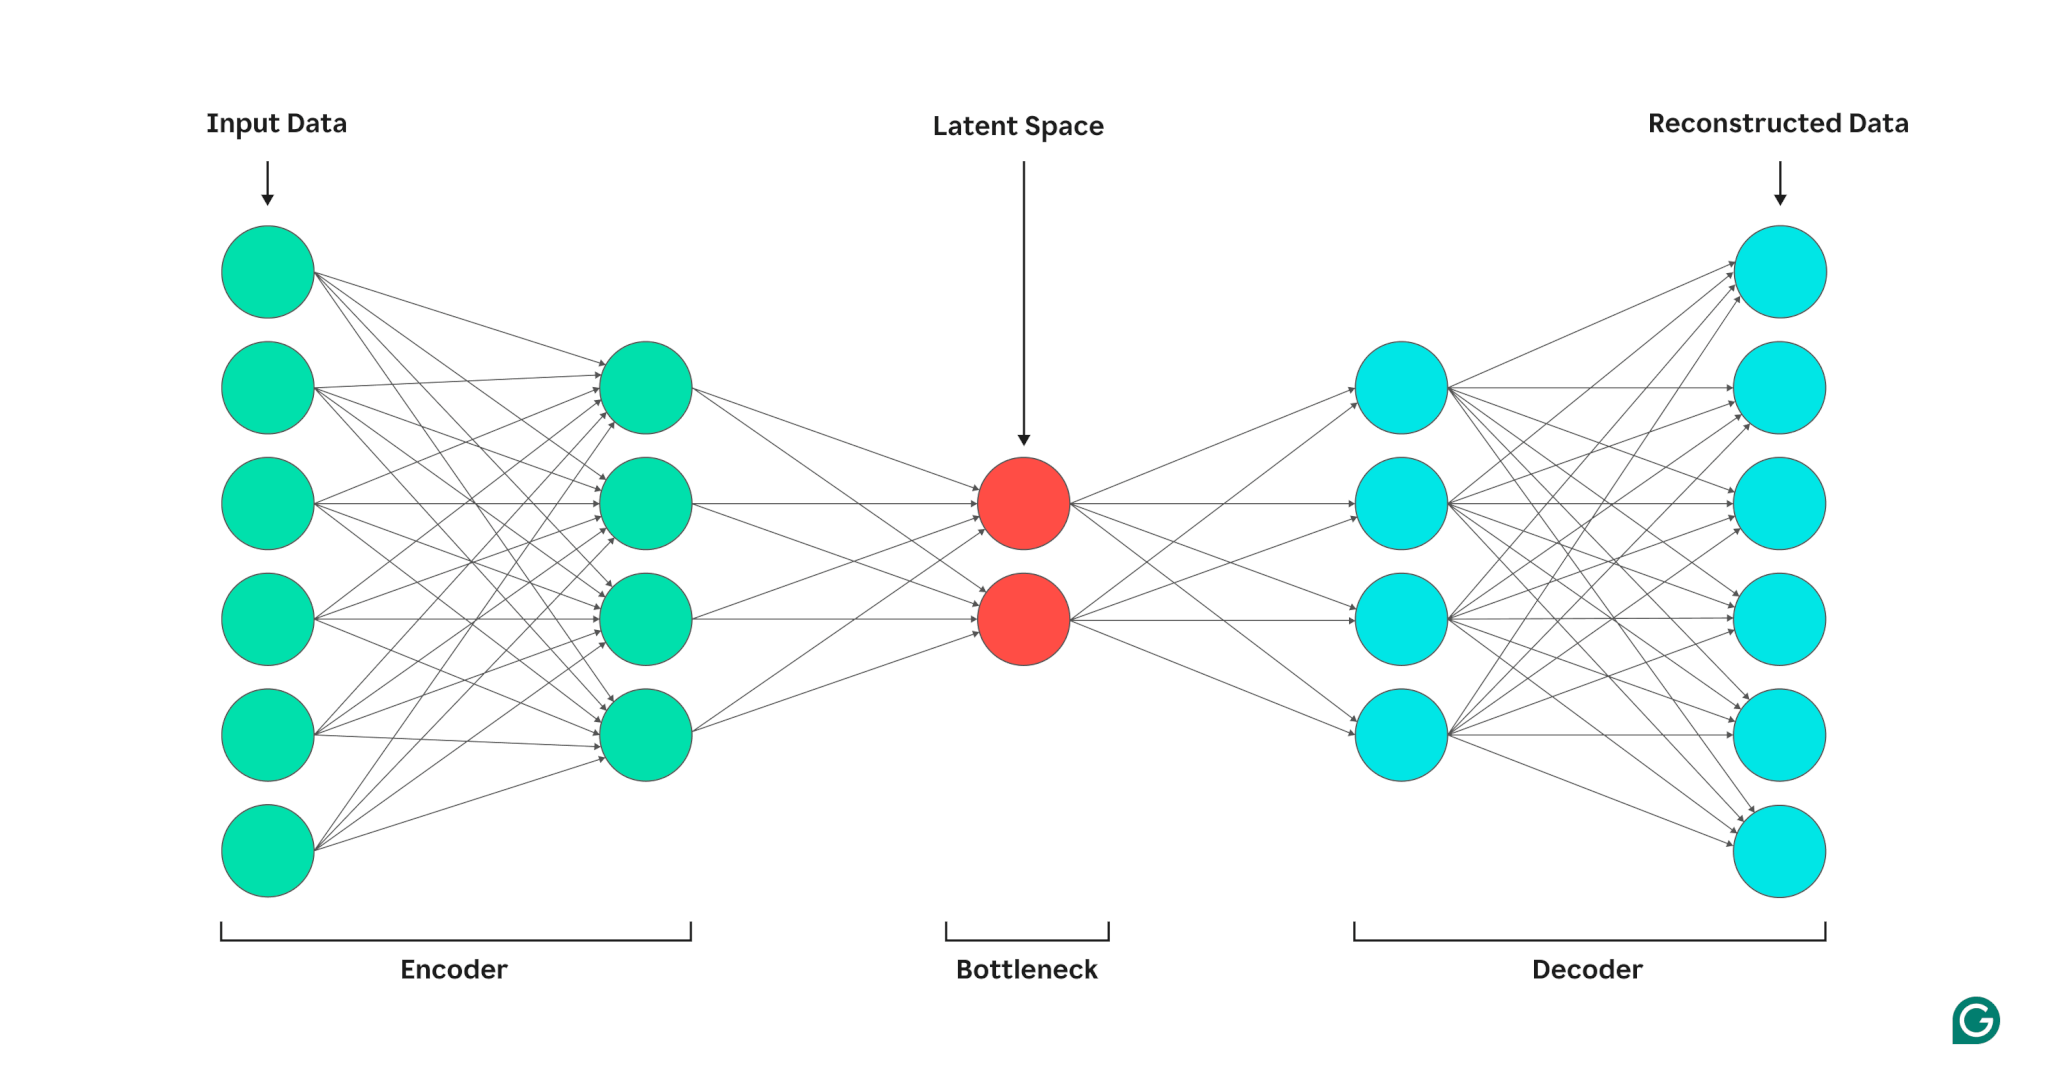


<br>

### 🧠 How does this Autoencoder work?

Unlike the other models we used, the autoencoder does **not** output a label or probability: It learns to **reconstruct the input** as accurately as possible, based on the structure it observes in the data.

>If a point is reconstructed **poorly**, we assume it's **anomalous**.  
>If it's reconstructed **well**, we assume it's **normal**.

This method focuses again - like the Gaussian baseline model - on modeling *normality* — just with a more flexible model: the difference is that the definition of “normal” is now learned via Deep Learning, and anomalies are detected based on how badly they are reconstructed — that is, by their reconstruction error.

This approach is:
- **Unsupervised during training**: we don’t use labels at all.
- **Supervised for threshold tuning**: we still use the validation set to set the anomaly threshold (just like before, with the Gaussian baseline model).

<br>

### 🧠 Neural Network architecture

More precisely, the Autoencoder is a symmetric feedforward Neural Network with two parts:

- The **encoder**, which compresses the input into a lower-dimensional representation (the **latent space**).
- The **decoder**, which tries to reconstruct the original input from this compressed code.

Both parts are trained **jointly** by minimizing the reconstruction error  
(we use **Mean Squared Error**, MSE, as the loss function).

We also use techniques like:

- **Batch Normalization**: to stabilize training.
- **Dropout**: to reduce overfitting.


In [ ]:
# 3.  Deep Learning methods: Autoencoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_cv_tensor = torch.FloatTensor(X_cv_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # Input = Output for autoencoder
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define the Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=16):
        super(Autoencoder, self).__init__()

        # Calculate layer sizes for a gradually decreasing architecture
        layer1_size = input_dim // 2
        layer2_size = layer1_size // 2

        # Ensure minimum size
        layer1_size = max(layer1_size, encoding_dim * 2)
        layer2_size = max(layer2_size, encoding_dim)

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, layer1_size),
            nn.BatchNorm1d(layer1_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer1_size, layer2_size),
            nn.BatchNorm1d(layer2_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer2_size, encoding_dim),
            nn.BatchNorm1d(encoding_dim),
            nn.ReLU(True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, layer2_size),
            nn.BatchNorm1d(layer2_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer2_size, layer1_size),
            nn.BatchNorm1d(layer1_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer1_size, input_dim),
            nn.Tanh()  # Output activation to match standardized data range
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    def encode(self, x):
        return self.encoder(x)

# Get input dimension from data
input_dim = X_train_scaled.shape[1]
print(f"Input dimension: {input_dim}")

# Create the autoencoder model
encoding_dim = min(16, input_dim // 4)  # Adjust encoding dimension based on input size
model = Autoencoder(input_dim, encoding_dim).to(device)
print(f"Encoding dimension: {encoding_dim}")
print(model)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Training function
def train_autoencoder(model, train_loader, num_epochs=100, patience=10):
    # For early stopping
    best_loss = float('inf')
    no_improve_epochs = 0

    # For plotting
    train_losses = []

    print("Training autoencoder...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for data, _ in train_loader:
            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, data)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)

        # Calculate epoch loss
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}')

        # Early stopping
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            no_improve_epochs = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_autoencoder.pth')
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Load the best model
    model.load_state_dict(torch.load('best_autoencoder.pth'))

    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses)
    plt.title('Autoencoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.show()

    return model


### 🏋️‍♀️ Training with Early Stopping

As we have seen before, we train the model on **normal data only**, using reconstruction loss as the objective.  
To avoid overfitting and speed up training, we use **early stopping**: if the loss doesn't improve after a number of epochs, we stop the training.

We store the model with the **lowest validation loss**, not the final epoch.  

---

<br>

Once trained, the autoencoder can be used as follows:

1. Feed the input to the model.
2. Compute the **reconstruction error** for each point.
3. Use a **threshold** on the reconstruction error to classify anomalies.

We select the threshold by looking at the reconstruction errors on the cross-validation set and using the **contamination rate** (i.e., percentage of anomalies) to determine the cutoff.  

<br>

In [ ]:
# Train the autoencoder
model = train_autoencoder(model, train_loader, num_epochs=200, patience=20)

# Function to compute reconstruction error
def compute_reconstruction_error(model, data_tensor):
    model.eval()
    with torch.no_grad():
        reconstructions = model(data_tensor)
        # Compute MSE for each sample
        mse = ((reconstructions - data_tensor) ** 2).mean(dim=1).cpu().numpy()
    return mse

# Compute reconstruction errors
train_errors = compute_reconstruction_error(model, X_train_tensor)
cv_errors = compute_reconstruction_error(model, X_cv_tensor)
test_errors = compute_reconstruction_error(model, X_test_tensor)

# Determine threshold for anomaly detection using cross-validation set
# We'll use the contamination rate from the cross-validation set
contamination = np.mean(y_cross_val)
print(f"Contamination rate from cross-validation set: {contamination:.4f}")

# Find the threshold that best separates normal and anomalous examples in the CV set
cv_errors_normal = cv_errors[y_cross_val == 0]
cv_errors_anomaly = cv_errors[y_cross_val == 1]

# Plot histogram of reconstruction errors by class
plt.figure(figsize=(12, 6))
plt.hist(cv_errors_normal, bins=50, alpha=0.5, label='Normal', color='blue')
plt.hist(cv_errors_anomaly, bins=50, alpha=0.5, label='Anomaly', color='red')
plt.axvline(x=np.percentile(cv_errors, 100 * (1 - contamination)),
            color='green', linestyle='dashed', linewidth=2,
            label=f'Threshold at {100 * (1 - contamination):.1f}th percentile')
plt.title('Reconstruction error distribution by class (Cross-Validation Set)')
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Set threshold at the percentile corresponding to the contamination rate
threshold = np.percentile(cv_errors, 100 * (1 - contamination))
print(f"Threshold for anomaly detection: {threshold:.6f}")

# Make predictions on test set
y_pred = (test_errors > threshold).astype(int)



### Evaluation metrics

 In addition to the usual metrics, we show the plot with the **reconstruction error** for each point in the test set.

- Each dot is a data point.
- Color indicates the true label:  
  - 🔵 Blue for **normal**  
  - 🔴 Red for **anomalies**
- The green dashed line is the **threshold** used to classify a point as anomalous.

What does this chart tell us?

- Samples **above the threshold** are predicted as anomalies
- Samples **below** are classified as normal
- We can directly spot:
  - **False positives**: blue dots above the line
  - **False negatives**: red dots below the line

This is a simple but effective diagnostic tool to evaluate the classifier's behavior **based on its internal logic** (reconstruction error).  
It's also a sanity check: are anomalies really harder to reconstruct?

<br>

---

<br>

### 📊 A note on visualizing results with PCA and latent space

After training the autoencoder, we extract the **internal (latent) representation** of the test set.  
This is the output of the encoder — a compressed and abstract version of each input.

To make it visible, we apply **PCA** to this latent space.

Why?

- The latent space has too many dimensions to visualize.
- PCA gives us the two principal directions where the model encodes most variation.
- We use one **latent-variable model (PCA)** to inspect another **latent-variable model (the autoencoder)**

> 🌀 Like in the movie *Inception*, this is a model **within** a model.  
> 🧠 We *dive into the mind of the Autoencoder* to see how it thinks —  
> not through raw inputs, but through how it compresses and reconstructs the world. In order to do that, we need PCA to simplify the situation.


We then:

- Color the points based on **true vs predicted anomalies**.
- Explore the **structure of the latent space**.
- Visualize **where the reconstruction error is high**, and how it affects anomaly decisions.

These plots are not just for show: they provide some **qualitative insight** into the model’s logic, blind spots, and failure modes.

<br>

In [ ]:
# Evaluate the autoencoder model
def evaluate_autoencoder(y_true, y_pred, reconstruction_errors, threshold):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\nAutoencoder performance:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Autoencoder')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, reconstruction_errors)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve - Autoencoder')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Visualize reconstruction error distribution
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(reconstruction_errors)),
                reconstruction_errors,
                c=['blue' if label == 0 else 'red' for label in y_true],
                alpha=0.5)
    plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold: {threshold:.4f}')
    plt.title('Reconstruction error for test set')
    plt.xlabel('Sample index')
    plt.ylabel('Reconstruction error')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return precision, recall, f1, roc_auc


# Visualize in PCA space
def visualize_autoencoder_pca(X, y_true, y_pred, reconstruction_errors, threshold):
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create a DataFrame for plotting
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    pca_df['Actual'] = y_true
    pca_df['Predicted'] = y_pred
    pca_df['Error'] = reconstruction_errors

    # Create classification categories
    pca_df['Category'] = 'Unknown'
    pca_df.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    pca_df.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    pca_df.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    pca_df.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_
    total_variance = sum(explained_variance)

    # Plot
    plt.figure(figsize=(12, 8))

    # Define colors and sizes
    colors = {'True Negative': 'gray', 'True Positive': 'black',
              'False Positive': 'red', 'False Negative': 'blue'}
    alphas = {'True Negative': 0.3, 'True Positive': 0.5,
              'False Positive': 0.8, 'False Negative': 0.8}
    sizes = {'True Negative': 30, 'True Positive': 40,
             'False Positive': 80, 'False Negative': 80}

    # Plot each category
    for category, group in pca_df.groupby('Category'):
        plt.scatter(group['PC1'], group['PC2'],
                    color=colors[category],
                    alpha=alphas[category],
                    s=sizes[category],
                    label=f"{category} ({len(group)})")

    plt.title(f'PCA Projection - Autoencoder\nExplained variance: {total_variance:.2%}', fontsize=16)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=14)
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Plot with reconstruction error as color intensity
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                c=pca_df['Error'],
                cmap='viridis',
                alpha=0.7,
                s=50)
    plt.colorbar(scatter, label='Reconstruction error')
    plt.title(f'PCA Projection with eeconstruction error\nExplained variance: {total_variance:.2%}', fontsize=16)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=14)
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Visualize in latent space
    model.eval()
    with torch.no_grad():
        latent_vectors = model.encode(X_test_tensor).cpu().numpy()

    # Apply PCA if the latent space has more than 2 dimensions
    if latent_vectors.shape[1] > 2:
        pca_latent = PCA(n_components=2)
        latent_2d = pca_latent.fit_transform(latent_vectors)
        explained_var = pca_latent.explained_variance_ratio_
        total_var = sum(explained_var)
        title_suffix = f"\nPCA Explained variance: {total_var:.2%}"
    else:
        latent_2d = latent_vectors
        title_suffix = ""

    # Create DataFrame for latent space visualization
    latent_df = pd.DataFrame(latent_2d, columns=['Dim1', 'Dim2'])
    latent_df['Actual'] = y_test
    latent_df['Predicted'] = y_pred
    latent_df['Error'] = reconstruction_errors

    # Create classification categories
    latent_df['Category'] = 'Unknown'
    latent_df.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    latent_df.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    latent_df.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    latent_df.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    # Plot in latent space by category
    plt.figure(figsize=(12, 8))
    for category, group in latent_df.groupby('Category'):
        plt.scatter(group['Dim1'], group['Dim2'],
                    color=colors[category],
                    alpha=alphas[category],
                    s=sizes[category],
                    label=f"{category} ({len(group)})")

    plt.title(f'Autoencoder latent space projection{title_suffix}', fontsize=16)
    plt.xlabel('Dimension 1', fontsize=14)
    plt.ylabel('Dimension 2', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Plot in latent space with reconstruction error as color
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(latent_df['Dim1'], latent_df['Dim2'],
                c=latent_df['Error'],
                cmap='viridis',
                alpha=0.7,
                s=50)
    plt.colorbar(scatter, label='Reconstruction error')
    plt.title(f'Autoencoder latent space with reconstruction error{title_suffix}', fontsize=16)
    plt.xlabel('Dimension 1', fontsize=14)
    plt.ylabel('Dimension 2', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Evaluate autoencoder performance
ae_metrics = evaluate_autoencoder(y_test, y_pred, test_errors, threshold)

# Visualize the autoencoder results
visualize_autoencoder_pca(X_test_scaled, y_test, y_pred, test_errors, threshold)

# Compare with previous models
# Add autoencoder results to the comparison DataFrame
results_df = pd.DataFrame([
    ("Autoencoder", ae_metrics[0], ae_metrics[1], ae_metrics[2])
], columns=['Model', 'Precision', 'Recall', 'F1 Score'])

# Print the results table
print("\nPerformance comparison:")
print(results_df.sort_values('F1 Score', ascending=False).to_string(index=False))

print("\nMemento: Baseline model performance:")
print(f"Precision: {MVG_precision:.4f}")
print(f"Recall: {MVG_recall:.4f}")
print(f"F1 Score: {MVG_f1:.4f}")


### 📈 Feature importance

We estimate feature importance by **zeroing out** each feature (one at a time) and measuring how much the **reconstruction error increases**.

This tells us which variables are most critical to the model's understanding of “normality.”  

> Useful for interpretability — especially in financial or operational risk settings.

<br>

In [ ]:
# Feature importance analysis using the autoencoder
def analyze_feature_importance(model, X_tensor, feature_names):
    """
    Analyze feature importance by measuring the impact of each feature on reconstruction error
    """
    model.eval()
    n_features = X_tensor.shape[1]
    importance_scores = []

    # Original reconstruction error
    with torch.no_grad():
        original_output = model(X_tensor)
        original_error = ((original_output - X_tensor) ** 2).mean(dim=0).cpu().numpy()

    # Measure impact of perturbing each feature
    for i in range(n_features):
        # Create a copy with the i-th feature perturbed
        perturbed_input = X_tensor.clone()
        perturbed_input[:, i] = torch.zeros_like(perturbed_input[:, i])

        with torch.no_grad():
            perturbed_output = model(perturbed_input)
            perturbed_error = ((perturbed_output - X_tensor) ** 2).mean(dim=0).cpu().numpy()

        # Importance is the increase in error when the feature is perturbed
        feature_importance = np.mean(perturbed_error - original_error)
        importance_scores.append(feature_importance)

    # Create DataFrame with feature importance
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores
    })

    # Sort by importance
    importance_df = importance_df.sort_values('Importance', ascending=False)

    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
    plt.title('Top 20 features by importance (Autoencoder)', fontsize=16)
    plt.xlabel('Importance Score', fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_df

# Analyze feature importance
if 'stationary_df' in locals() and hasattr(stationary_df, 'columns'):
    feature_names = stationary_df.columns
    feature_importance = analyze_feature_importance(model, X_test_tensor, feature_names)
    print("\nTop 10 most important features:")
    print(feature_importance.head(10))


<br>

This notebook you've just completed provides a good foundation for comparing anomaly detection techniques.

Now it's your turn to go further.

There are a lot of things you can do. Don't do them all, I'll just give you some ideas... Do reasonable things.

<br>

---

## HINTs

### 1. Improve the existing models
- You can fine-tune them using hyperparameter optimization libraries such as **[Optuna](https://www.google.com/url?q=https%3A%2F%2Foptuna.readthedocs.io%2Fen%2Fstable%2Findex.html%23)**, or try different scalers, data splits, loss functions, etc.  
- Once optimized, compare them on the same test set using the existing evaluation pipeline. It is also interesting to use synthetic data to compare different models.
- Also, explore **explainability**: SHAP, LIME, or [Gradient-based methods](https://pytorch.org/tutorials/beginner/introyt/captumyt.html) for neural models, but you already know.

---

### 🧪 2. Explore alternative models

Here are a few suggestions, of varying difficulty:

#### 📌 Variational Autoencoder (VAE)
- Adds a **Gaussian prior** to the latent space.
- Uses a loss function with two terms: reconstruction + **KL divergence**.
- Encourages **smoother generalization** and **better anomaly scoring**.
- Can also be used to **generate synthetic samples** of normal data.
- See:
  - [An Introduction to Variational Autoencoders](https://arxiv.org/abs/1906.02691).
  - [What is a variational autoencoder?](https://www.ibm.com/think/topics/variational-autoencoder).
  - [Deep Learning - Autoencoders](https://www.deeplearningbook.org/contents/autoencoders.html).

#### 📌 PCA and Linear Autoencoders
- PCA is equivalent to a **linear autoencoder** with no activation function.
- The reconstruction error can be used as anomaly score.
- Consider extensions, e.g., **[Kernel PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html#sklearn.decomposition.KernelPCA)**, or **[Sparse PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html#sklearn.decomposition.SparsePCA)**.

#### 📌 [Isolation Mondrian Forest](https://paperswithcode.com/paper/isolation-mondrian-forest-for-batch-and)
- An enhancement of Isolation Forest with better robustness and generalization.

#### 📌 Gradient Boosted Trees (e.g., XGBoost)
- Try with imbalanced settings and anomaly-aware loss functions.

#### 📌 COPOD (Copula-Based Outlier Detection)
- A **density-based** method that models multivariate dependencies via [Copulas](https://en.wikipedia.org/wiki/Copula_(statistics)) - see also [A Practical Introduction to Copula](https://hudson-and-thames-arbitragelab.readthedocs-hosted.com/en/latest/copula_approach/copula_brief_intro.html).  
- More flexible than MVG and even Local Outlier Factor.
- For a good Python library, see [COPOD: Copula-Based Outlier Detection](https://arxiv.org/abs/2009.09463) and for the library I suggest [PyOD](https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.copod.COPOD)

#### 📌 [LSTM](https://en.wikipedia.org/wiki/Long_short-term_memory) Autoencoder
- Useful for time series: captures temporal dependencies.
- Requires reshaping the data into sequences.
- See for example [A Gentle Introduction to LSTM Autoencoders](https://machinelearningmastery.com/lstm-autoencoders/),

#### 📌 [GAN](https://en.wikipedia.org/wiki/Generative_adversarial_network) for Anomaly Detection
- Use the **discriminator** to detect whether a point is "realistic".
- Similar principle to an autoencoder, but adversarial.
- Hard.
- See [A Survey on GANs for Anomaly Detection](https://arxiv.org/pdf/1906.11632).


>In general, **the library [PyOD](https://pyod.readthedocs.io/en/latest/)** includes a great variety of Anomaly Detection models, and the implementation in PyOD is efficient and well tested. It follows scikit-learn conventions (fit, predict, etc.). Many of the models mentioned, and many more, can be found there.So, enjoy...

---

### 🧭 3. Add financial domain knowledge

Machine Learning models can be greatly improved by embedding financial structure, i.e. business/financial knowledge:

- **Feature selection** by asset class, instrument type, or region.
- **Feature engineering** via statistical aggregates or dimensionality reduction (e.g. PCA per cluster of correlated assets).
- **Anomaly interpretation** based on macro/market context (e.g. clustering anomalies by cause).

---

### 🎯 4. Ensemble methods & uncertainty estimation

I know I'm repetitive. But. Another powerful direction is to build **an ensemble of models** (or model averaging). For instance:

- Combine **different anomaly detectors** (e.g. Autoencoder + LOF + Isolation Forest).
- Or use an ensemble of **Autoencoders** with different initializations (they provide different results). You can:
  - Average their anomaly scores
  - Or use their **disagreement (variance)** as a **proxy for predictive uncertainty**: models that disagree on a sample may be revealing an ambiguous or borderline case – which could be flagged for deeper analysis.

The ensemble approach helps mitigate overfitting and improves **robustness to noise** and model misspecification.

---

### 🔁 5. Semi-Supervised Anomaly Detection and Active Learning

When labels are scarce or expensive to obtain — a common situation in finance — it can be useful to explore **semi-supervised learning**, where:

- You start from a small set of labeled anomalies (or normal points).
- And propagate this information to the unlabeled data using **label propagation** or **graph-based methods**.

Another promising avenue is **[Active Learning](https://en.wikipedia.org/wiki/Active_learning_(machine_learning))**, where the model can **query** for the label of the most uncertain points — typically the ones near the decision boundary or where models disagree. So if the model is undecided, a Sapiens (human in the loop) decides.

This is especially relevant when a domain expert (e.g., a risk officer - you can assume you are a team of risk managers) can confirm whether specific events are truly anomalous. And the model learns.

📚 Some reading:

- [Chapelle, Scholkopf, Zien (2006)](https://www.oxfordreference.com/view/10.1093/acref/9780199676844.001.0001/acref-9780199676844): *Semi-Supervised Learning* — the classic reference on the topic  
- [Budd et al. (2021)](https://arxiv.org/abs/1906.10685): *A Survey on Active Learning and Human-in-the-Loop for Anomaly Detection* — a modern overview

These approaches allow us to **embed expert knowledge into the model loop** without requiring full supervision — a realistic compromise in most financial contexts.
